In [1]:
import json
import matplotlib as mpl
from pathlib import Path
import gzip
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from marvin import config
from marvin.tools import Maps
from marvin.tools.cube import Cube
from scipy.ndimage import map_coordinates
from scipy.ndimage import label, generic_filter
from mpl_toolkits.axes_grid1 import make_axes_locatable
CACHE_ROOT = Path("/home/jinelfy/TW_external/intermediate_cache")
ELLIPSE_DIR = CACHE_ROOT / "ellipse"
PA_DIR = CACHE_ROOT / "pa_disk"
MASTER_CSV = CACHE_ROOT / "master_table.csv"
%config InlineBackend.figure_formats = ['svg']
PA_DIR.mkdir(parents=True, exist_ok=True)
scale_plot = 1e4

#------------------------------------------------------------
#              Drawing format settings
#------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "cm",

    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    "axes.linewidth": 2.0,
    "legend.frameon": False,

    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})


[INFO]: No release version set. Setting default to DR17
[WARNING]: path /home/jinelfy/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/dapall-v3_1_1-3.1.0.fits cannot be found. Setting dapall to None. (MarvinUserWarning)


## Load Recast Map From PA_DISK

In [2]:
## 0. basic setup
# =========================================================
galaxy_id = "8312-12702"

pixscale = 0.5   # arcsec / pix for MaNGA reconstructed cube
Re=7.67477
from pathlib import Path

CACHE_ROOT = Path("/home/jinelfy/TW_external/intermediate_cache")
ELLIPSE_DIR = CACHE_ROOT / "ellipse"
PA_DIR = CACHE_ROOT / "pa_disk"
MASTER_CSV = CACHE_ROOT / "master_table.csv"
TW_CENTER_DIR = CACHE_ROOT / "tw_center"
TW_CENTER_DIR.mkdir(parents=True, exist_ok=True)
TW_MC_DIR = TW_CENTER_DIR / f"pa_disk_recast_mc_tw_{galaxy_id}"
df_master = pd.read_csv(MASTER_CSV)
master_csv_table = df_master[df_master["plateifu"] == galaxy_id].iloc[0]
Vsys_ref = master_csv_table["Vsys_ref"]
PA_disk_kin = master_csv_table["PA_disk_kin_mode_deg_0_180"]-90
print('Vsys_ref=',Vsys_ref,"PA_disk_mode=",PA_disk_kin)


Vsys_ref= -8.405278125679079 PA_disk_mode= 6.0


In [3]:

def load_json(path):
    path = Path(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

# =========================================================
# 2. reload MaNGA data products
# =========================================================

def load_manga_maps_modelcube_dr17(
    galaxy_id="8312-12702",
    daptype="SPX-MILESHC-MASTARSSP",
    sas_root="/home/jinelfy/sas",
):
    plate, ifu = galaxy_id.split("-")

    config.mode = "local"
    config.access = "public"
    config.setRelease("DR17")

    base = Path(sas_root) / "dr17/manga/spectro/analysis/v3_1_1/3.1.0" / daptype / plate / ifu

    maps_file = base / f"manga-{galaxy_id}-MAPS-{daptype}.fits.gz"
    logcube_file = base / f"manga-{galaxy_id}-LOGCUBE-{daptype}.fits.gz"

    if not maps_file.exists():
        raise FileNotFoundError(
            f"MAPS file not found:\n{maps_file}\n\n"
            f"Download the {daptype} product first, or check your sas_root."
        )

    maps = Maps(filename=str(maps_file))

    # This should load the corresponding LOGCUBE/modelcube with the same DAPTYPE.
    modelcube = maps.getModelCube()

    return maps, modelcube, maps_file, logcube_file
# 1）Read from SPX(no-binning)
galaxy_id = "8312-12702"
my_cube = Cube(plateifu=galaxy_id)   # download first in code Marvins
maps, modelcube, maps_file, logcube_file = load_manga_maps_modelcube_dr17(
    galaxy_id=galaxy_id,
    daptype="SPX-MILESHC-MASTARSSP",
    sas_root="/home/jinelfy/sas",
)
# 2）best-fitting continuum cube over 5600–6750 Å
stellar_fit = modelcube.stellarcont_fit.value.astype(float)

stellar_vel = maps.stellar_vel.value.astype(float)
stellar_vel[stellar_vel == 0] = np.nan

ha_flux = maps.emline_gflux_ha_6564.value.astype(float)
ha_flux[ha_flux == 0] = np.nan

ha_vel = maps.emline_gvel_ha_6564.value.astype(float)
ha_vel[ha_vel == 0] = np.nan

wave = my_cube.data['WAVE'].data

# 3) 波长范围
wave_obs = my_cube.data['WAVE'].data.astype(float)

assert stellar_fit.shape[0] == len(wave_obs), \
    f"Spectral axis mismatch: stellar_fit.shape[0]={stellar_fit.shape[0]}, len(wave_obs)={len(wave_obs)}"

z = maps.nsa['z']
wave_rest = wave_obs / (1.0 + z)
mask = (wave_rest >= 5600.0) & (wave_rest <= 6750.0)
dlam = np.nanmedian(np.diff(wave_rest[mask]))

stellar_surfb = np.nansum(stellar_fit[mask, :, :], axis=0) * dlam
stellar_vel = maps.stellar_vel.value      #Vlos
stellar_vel[stellar_vel==0]=np.nan

ha_flux = maps.emline_gflux_ha_6564.value #flux
ha_vel = maps.emline_gvel_ha_6564.value   #vel
ha_vel[ha_vel==0]=np.nan


def nanmedian_filter(data, size):

    # 对含 NaN 的数组做 nanmedian 滤波。
    return generic_filter(data,function=lambda x: np.nanmedian(x),size=size,mode='nearest')

# =========================================================
# 4. True center from RA/Dec  ->  Xref, Yref coordinate system
# =========================================================
ra0 = my_cube.ra
dec0 = my_cube.dec
wcs2d = my_cube.wcs.celestial

x_pix, y_pix = wcs2d.world_to_pixel_values(ra0, dec0)
def Build_xy_arcsec_with_center(shape, x0_pix, y0_pix, pixscale_arcsec=0.5):
    """
    根据真实星系中心 (x0_pix, y0_pix) 构建以该中心为原点的二维坐标网格。
    ----
    shape : 2D 数据形状 (ny, nx)
    x0_pix, y0_pix : 真实中心在像素坐标中的位置（可为非整数）
    pixscale_arcsec : 每像素角尺度，MaNGA 重建图通常为 0.5 arcsec/pix
    返回
    ----
    x_arcsec, y_arcsec : 以真实中心为原点的二维坐标网格，单位 arcsec
    extent_arcsec      : imshow 可直接使用的 extent，单位 arcsec
    center_index       : 最接近真实中心的整数像素索引 (cy, cx)
    """
    ny, nx = shape
    yy, xx = np.mgrid[:ny, :nx]  # 生成原始像素索引网格

    # 把像素坐标转换成“以真实中心为原点”的 arcsec 坐标
    x_arcsec = (xx - x0_pix) * pixscale_arcsec
    y_arcsec = (yy - y0_pix) * pixscale_arcsec

    # 与 imshow(origin='lower') 配套的显示边界
    extent_arcsec = [
        -x0_pix * pixscale_arcsec,
        ((nx - 1) - x0_pix) * pixscale_arcsec,
        -y0_pix * pixscale_arcsec,
        ((ny - 1) - y0_pix) * pixscale_arcsec,
    ]

    # 找到距离 (0,0) 最近的实际像素，用于 island 标记时的“中心像素”
    cx = int(np.argmin(np.abs(x_arcsec[0, :])))
    cy = int(np.argmin(np.abs(y_arcsec[:, 0])))

    return x_arcsec.astype(float), y_arcsec.astype(float), extent_arcsec, (cy, cx)

x_arcsec, y_arcsec, extent_arcsec, center_index = Build_xy_arcsec_with_center(
    shape=stellar_surfb.shape,
    x0_pix=x_pix,
    y0_pix=y_pix,
    pixscale_arcsec=pixscale
)
# In this coordinate system:
Xref_arcsec = 0.0
Yref_arcsec = 0.0
x_axis = x_arcsec[0, :].astype(float)
y_axis = y_arcsec[:, 0].astype(float)

# =========================================================
#5.  Reload the recast map
# =========================================================
load_path = Path("./saved_outputs/fig4_out.pkl")

with open(load_path, "rb") as f:
    fig4_out = pickle.load(f)
# print("Loaded fig4_out keys:")
# for k in fig4_out.keys():
#      print("  -", k)
# Recasted stellar map used below
stellar_sigma_recast = fig4_out["stellar_sigma_recast"] #For this Yc / Eq.6 step, I use the stellar-only valid mask, because here Σ is the stellar surface brightness.
ha_sigma_recast = fig4_out["ha_sigma_recast"]
valid_mask_star = fig4_out["display_mask_star"]
valid_mask_ha = fig4_out["display_mask_ha"]

print("Recast stellar map ready.")

[WARNING]: path /home/jinelfy/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/dapall-v3_1_1-3.1.0.fits cannot be found. Setting dapall to None. (MarvinUserWarning)


Recast stellar map ready.


In [4]:
# 1. helper functions for Yc fine-tuning
# =========================================================
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# tracer label helpers
# ---------------------------------------------------------
def _normalize_tracer_name(tracer):
    tracer_str = str(tracer).strip().lower()
    if tracer_str in {"stellar", "stars", "star"}:
        return "stellar"
    if tracer_str in {"ha", "halpha", "h_alpha", "hα", "h-alpha"}:
        return "ha"
    return tracer_str

def _tracer_math_suffix(tracer):
    tracer_key = _normalize_tracer_name(tracer)
    if tracer_key == "stellar":
        return r"$(\rm Stars)$"
    if tracer_key == "ha":
        return r"$(\rm H\alpha)$"
    return rf"$({tracer})$"

def _xsigma_ylabel(tracer):
    return rf"$\int \,\, X\,\Sigma\,dX$ {_tracer_math_suffix(tracer)}"

def _vsigma_ylabel(tracer):
    return rf"$\int \,\, V_{{\parallel}}\,\Sigma\,dX$ {_tracer_math_suffix(tracer)}"

def _tw_ratio_ylabel(tracer):
    return (
        r"$ \int \,\, (V_{\parallel})\,\Sigma\,dX /"
        r" \int \,\, X\,\Sigma\,dX $ "
        + _tracer_math_suffix(tracer)
    )

def find_slit_centers(bar_half_width_arcsec, slit_spacing_arcsec=1.0): #间隔
    """
    Generate |Y| offsets (arcsec) for slit centers covering the bar.
    Example:
        bar_half_width ~ 5.2 arcsec  -> [2.0, 4.0]
    """
    ymax = float(bar_half_width_arcsec)
    yabs_list = np.arange(slit_spacing_arcsec, ymax + 1e-9, slit_spacing_arcsec)
    return [float(v) for v in yabs_list if v > 0]


def normalize_explicit_yabs_list(explicit_yabs_list=None, bar_half_width_arcsec=None, slit_spacing_arcsec=1.0):
    """
    Return an explicit sorted list of positive |Y| slit centers in arcsec.
    If explicit_yabs_list is None, generate it from bar_half_width_arcsec and slit_spacing_arcsec.
    """
    if explicit_yabs_list is None:
        if bar_half_width_arcsec is None:
            raise ValueError("Provide either explicit_yabs_list or bar_half_width_arcsec.")
        vals = find_slit_centers(
            bar_half_width_arcsec=bar_half_width_arcsec,
            slit_spacing_arcsec=slit_spacing_arcsec,
        )
    else:
        vals = [float(v) for v in explicit_yabs_list if float(v) > 0]

    vals = sorted(set([float(v) for v in vals]))
    return vals


def select_slit_boxes(y_axis, y_center_arcsec, slit_width_arcsec=2.0): #
    """
    Select rows belonging to a box slit centered at y_center_arcsec,
    with total width = slit_width_arcsec.
    """
    half_w = 0.5 * slit_width_arcsec
    row_sel = np.abs(y_axis - y_center_arcsec) <= (half_w + 1e-12)
    return row_sel


def find_symmetric_x_max(valid_mask, row_sel, x_axis, x_center_arcsec=0.0):
    """
    For the selected slit rows, find the longest symmetric contiguous X-range
    around x_center_arcsec such that all involved pixels are valid.
    """
    row_idx = np.where(row_sel)[0]
    if len(row_idx) == 0:
        return None

    col_ok = np.all(valid_mask[row_idx, :], axis=0)
    if not np.any(col_ok):
        return None

    x0_idx = int(np.argmin(np.abs(x_axis - x_center_arcsec)))
    if not col_ok[x0_idx]:
        return None

    left = x0_idx
    while left - 1 >= 0 and col_ok[left - 1]:
        left -= 1

    right = x0_idx
    while right + 1 < len(col_ok) and col_ok[right + 1]:
        right += 1

    dx = min(x0_idx - left, right - x0_idx)
    if dx < 1:
        return None

    left = x0_idx - dx
    right = x0_idx + dx
    return x0_idx, left, right


def int_sigma_iny(sigma_map, row_sel, left, right, dy_arcsec):
    """
    Collapse Σ(x,y) over slit width in y:
        S(x) = ∫_slit Σ(x,y) dy
    """
    sigma_prof = np.nansum(sigma_map[row_sel, left:right+1], axis=0) * dy_arcsec
    return sigma_prof


def int_xsigma_inx(x_seg, sigma_prof):
    """
    Build cumulative denominator profile:
        D(X) = ∫_{-X}^{+X} x * S(x) dx
    where S(x) = ∫_slit Σ(x,y) dy
    """
    x_seg = np.asarray(x_seg, dtype=float)
    sigma_prof = np.asarray(sigma_prof, dtype=float)

    x0_idx = int(np.argmin(np.abs(x_seg)))   #（index）of minimum value
    max_dx = min(x0_idx, len(x_seg) - 1 - x0_idx)

    X_half = []  # Upper limit of integration 𝑋 
    D_X = []   # Value D(𝑋) at corresponding 𝑋 

    for dx in range(1, max_dx + 1):
        sl = slice(x0_idx - dx, x0_idx + dx + 1)
        xx = x_seg[sl]
        ss = sigma_prof[sl]

        good = np.isfinite(xx) & np.isfinite(ss)
        if np.count_nonzero(good) < 2:
            continue

        X_half.append(np.nanmax(np.abs(xx[good])))
        D_X.append(np.trapz(xx[good] * ss[good], xx[good]))  #np.trapz: trapezoidal integration
                        #int(    X     *  \Sigma )dX
    return np.asarray(X_half), np.asarray(D_X)

def int_sigma_inx(x_arr, sigma_arr):
    """
    Cumulative integral of Sigma along x:
        S(x_k) = \int_{-x_k}^{+x_k} Sigma dX
    implemented as cumulative sum on the symmetric x grid.

    Returns
    -------
    x_use : 1D array
        same x grid used for cumulative arrays
    Scum : 1D array
        cumulative \int Sigma dX
    """
    x_arr = np.asarray(x_arr, dtype=float)
    sigma_arr = np.asarray(sigma_arr, dtype=float)

    good = np.isfinite(x_arr) & np.isfinite(sigma_arr)
    x_use = x_arr[good]
    s_use = sigma_arr[good]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    dx = np.gradient(x_use)
    Scum = np.cumsum(s_use * dx)
    return x_use, Scum

def obtain_slit_pair_profiles(
    sigma_map,
    valid_mask,
    x_axis,
    y_axis,
    yc_arcsec,
    yabs_arcsec,
    slit_width_arcsec=2.0,
    x_center_arcsec=0.0,
):
    """
    Build a symmetric slit pair around candidate Yc:
        + slit center at yc + yabs
        - slit center at yc - yabs

    Returns common symmetric x-extent and the collapsed stellar Σ profiles
    for the positive and negative slit.
    """
    dy_arcsec = np.abs(y_axis[1] - y_axis[0])

    row_sel_pos = select_slit_boxes(
        y_axis, yc_arcsec + yabs_arcsec, slit_width_arcsec=slit_width_arcsec
    )
    row_sel_neg = select_slit_boxes(
        y_axis, yc_arcsec - yabs_arcsec, slit_width_arcsec=slit_width_arcsec
    )

    if (not np.any(row_sel_pos)) or (not np.any(row_sel_neg)):
        return None

    # common x-extent must be valid for BOTH slit bands
    row_sel_union = row_sel_pos | row_sel_neg
    extent = find_symmetric_x_max(
        valid_mask=valid_mask,
        row_sel=row_sel_union,
        x_axis=x_axis,
        x_center_arcsec=x_center_arcsec,
    )
    if extent is None:
        return None

    x0_idx, left, right = extent
    x_seg = x_axis[left:right+1]

    sigma_prof_pos = int_sigma_iny(  # S(X) profile
        sigma_map, row_sel_pos, left, right, dy_arcsec=dy_arcsec
    )
    sigma_prof_neg = int_sigma_iny(
        sigma_map, row_sel_neg, left, right, dy_arcsec=dy_arcsec
    )

    # Eq. 6 luminosity difference for this slit pair
    flux_pos = np.trapz(sigma_prof_pos, x_seg)
    flux_neg = np.trapz(sigma_prof_neg, x_seg)
    L_pair = flux_pos - flux_neg

    return {
        "yabs_arcsec": float(yabs_arcsec),
        "yc_arcsec": float(yc_arcsec),
        "x_seg": x_seg,
        "sigma_prof_pos": sigma_prof_pos,
        "sigma_prof_neg": sigma_prof_neg,
        "flux_pos": float(flux_pos),
        "flux_neg": float(flux_neg),
        "L_pair": float(L_pair),
        "row_sel_pos": row_sel_pos,
        "row_sel_neg": row_sel_neg,
        "y_center_pos": float(yc_arcsec + yabs_arcsec), #slit position in y
        "y_center_neg": float(yc_arcsec - yabs_arcsec),
    }
# ==============================
#        Yc fine-tuning
# ==============================
def find_Yc_best1(
    sigma_map,
    valid_mask,
    x_axis,
    y_axis,
    yc_arcsec,
    bar_yabs_list,
    slit_width_arcsec=2.0,
    x_center_arcsec=0.0,
):
    """
    use:
        mimimum value of: objective = sum( L_pair^2 ) over all bar-covering symmetric slit pairs.
        This avoids accidental cancellation between different slit pairs.
    """
    pair_list = []

    for yabs in bar_yabs_list:
        out = obtain_slit_pair_profiles(
            sigma_map=sigma_map,
            valid_mask=valid_mask,
            x_axis=x_axis,
            y_axis=y_axis,
            yc_arcsec=yc_arcsec,
            yabs_arcsec=yabs,
            slit_width_arcsec=slit_width_arcsec,
            x_center_arcsec=x_center_arcsec,
        )
        if out is not None:
            pair_list.append(out)

    if len(pair_list) == 0:
        return np.nan, pair_list

    objective = np.sum([p["L_pair"]**2 for p in pair_list])
    return float(objective), pair_list


def find_Yc_best2(
    sigma_map,
    valid_mask,
    x_axis,
    y_axis,
    yref_arcsec=0.0,
    pixscale_arcsec=0.5,
    bar_half_width_arcsec=4.0,
    slit_spacing_arcsec=2.0,
    slit_width_arcsec=2.0,
    max_offset_spaxel=1,
    spaxel_step=0.25,
):
    """
    Scan Yc in [Yref - 1 spaxel, Yref + 1 spaxel].
    """
    bar_yabs_list = normalize_explicit_yabs_list(
        explicit_yabs_list=explicit_yabs_list,
        bar_half_width_arcsec=bar_half_width_arcsec,
        slit_spacing_arcsec=slit_spacing_arcsec,
    )

    # yc_grid = np.linspace(
    #     yref_arcsec - pixscale_arcsec,
    #     yref_arcsec + pixscale_arcsec,
    #     ngrid
    # )
    spaxel_offsets = np.arange(-max_offset_spaxel, max_offset_spaxel + 1e-9, spaxel_step)
    yc_grid = yref_arcsec + spaxel_offsets * pixscale_arcsec

    records = []
    for yc in yc_grid:
        obj, pair_list = find_Yc_best1(
            sigma_map=sigma_map,
            valid_mask=valid_mask,
            x_axis=x_axis,
            y_axis=y_axis,
            yc_arcsec=yc,
            bar_yabs_list=bar_yabs_list,
            slit_width_arcsec=slit_width_arcsec,
            x_center_arcsec=0.0,
        )

        records.append({
            "yc_arcsec": float(yc),
            "objective": obj,
            "n_pairs": len(pair_list),
            "pair_list": pair_list,
        })

    good = np.array([np.isfinite(r["objective"]) for r in records], dtype=bool)
    if not np.any(good):
        raise RuntimeError("No valid Yc candidate found in the scan range.")

    idx_best = np.nanargmin([r["objective"] if np.isfinite(r["objective"]) else np.nan for r in records])
    best = records[idx_best]
    return records, best, bar_yabs_list

# diagnostic plot
def testdraw_Yc_scan(records, yref_arcsec=0.0, show=True):
    yc = np.array([r["yc_arcsec"] for r in records], dtype=float)
    obj = np.array([r["objective"] for r in records], dtype=float)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(yc, obj, color="black", lw=1.0)
    ax.scatter(yc, obj, s=18, color="black")
    ax.axvline(yref_arcsec, color="gray", ls="--", lw=1.0, label=r"$Y_{\rm ref}$")
    ax.set_xlabel(r"$Y_c$ (arcsec)")
    ax.set_ylabel(r"$\sum L_{\rm pair}^2$")
    ax.set_title(r"$Y_c$ fine-tuning")
    ax.legend(frameon=False)
    ax.set_ylim(2e6,4e6)
    if show:
        plt.show()
    return fig, ax

def testdraw_xsigma_at_best_yc(
    best_record,
    yabs_to_plot=(2.0, 4.0),
    tracer="stellar",
    show=True,
):
    pair_map = {float(p["yabs_arcsec"]): p for p in best_record["pair_list"]}

    fig, ax = plt.subplots(figsize=(6, 4))

    for yabs in yabs_to_plot:
        yabs = float(yabs)
        if yabs not in pair_map:
            print(f"Warning: yabs={yabs:.1f} arcsec not available at best Yc.")
            continue

        pair = pair_map[yabs]
        color = "red" if np.isclose(yabs, 2.0) else "b"

        # + slit
        Xp, Dp = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_pos"])
        ax.plot(Xp, Dp /scale_plot, color=color, lw=1.0)
        ax.plot(
            Xp, Dp/scale_plot,
            linestyle="none",
            marker="o",
            mec=color,
            mfc="none",
            ms=4.8,
            label=rf"$+{int(yabs)}''$"
        )

        # - slit
        Xm, Dm = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_neg"])

        ax.plot(Xm, Dm/scale_plot, color=color, lw=1.0)
        ax.plot(
            Xm, Dm/scale_plot,
            linestyle="none",
            marker="o",
            mec=color,
            mfc=color,
            ms=4.8,
            label=rf"$-{int(yabs)}''$"
        )

    ax.axvline(Re, color="gray", ls="--", lw=0.9)
    ax.set_xlabel(r"$X$ (arcsec)")
    ax.set_ylim(-4.9,4.9)
    ax.set_ylabel(_xsigma_ylabel(tracer))
    ax.set_title(
        rf"best $Y_c$ = {best_record['yc_arcsec']:.2f} arcsec"
    )
    ax.legend(frameon=False, ncol=2)

    if show:
        plt.show()
    return fig, ax

# =========================================================
# 10. Xc + Vsys fine-tuning
# =========================================================

def int_vsigma_inx(x_seg, sigma_prof, vel_prof, vsys=0.0):
    """
    Build cumulative numerator profile:
        N(X) = ∫_{-X}^{+X} [V(x)-Vsys] * S(x) dx
    where
        S(x) = ∫_slit Σ(x,y) dy
        V(x) = luminosity-weighted slit velocity along x
    """
    x_seg = np.asarray(x_seg, dtype=float)
    sigma_prof = np.asarray(sigma_prof, dtype=float)
    vel_prof = np.asarray(vel_prof, dtype=float)

    x0_idx = int(np.argmin(np.abs(x_seg)))
    max_dx = min(x0_idx, len(x_seg) - 1 - x0_idx)

    X_half = []
    XS = []

    for dx in range(1, max_dx + 1):
        sl = slice(x0_idx - dx, x0_idx + dx + 1)
        xx = x_seg[sl]
        ss = sigma_prof[sl]
        vv = vel_prof[sl]

        good = np.isfinite(xx) & np.isfinite(ss) & np.isfinite(vv)
        if np.count_nonzero(good) < 2:
            continue

        X_half.append(np.nanmax(np.abs(xx[good])))
        XS.append(np.trapz((vv[good] - vsys) * ss[good], xx[good]))

    return np.asarray(X_half), np.asarray(XS)


def int_velocity_iny(sigma_map, vel_map, row_sel, left, right, dy_arcsec): #Σ-weighting V
    """
    Collapse V(x,y) across slit width in y using Σ-weighting:
        S(x) = ∫_slit Σ dy
        V(x) = [∫_slit V Σ dy] / [∫_slit Σ dy]
    """
    sigma_block = sigma_map[row_sel, left:right+1]
    vel_block   = vel_map[row_sel, left:right+1]

    sigma_prof = np.nansum(sigma_block, axis=0) * dy_arcsec
    vsigma_prof = np.nansum(vel_block * sigma_block, axis=0) * dy_arcsec

    vel_prof = np.full_like(sigma_prof, np.nan, dtype=float)
    good = np.isfinite(sigma_prof) & (np.abs(sigma_prof) > 0)
    vel_prof[good] = vsigma_prof[good] / sigma_prof[good]

    return sigma_prof, vel_prof


def obtain_single_slit_profile_with_velocity(
    sigma_map,
    vel_map,
    valid_mask,
    x_axis,
    y_axis,
    xc_arcsec,
    y_center_arcsec,
    slit_width_arcsec=2.0,
):
    """
    Build one explicit slit centered at y_center_arcsec.
    Used for the central slit (0 arcsec) in the TW fitting plot.
    """
    dy_arcsec = np.abs(y_axis[1] - y_axis[0])

    row_sel = select_slit_boxes(
        y_axis, y_center_arcsec, slit_width_arcsec=slit_width_arcsec
    )
    if not np.any(row_sel):
        return None

    extent = find_symmetric_x_max(
        valid_mask=valid_mask,
        row_sel=row_sel,
        x_axis=x_axis,
        x_center_arcsec=xc_arcsec,
    )
    if extent is None:
        return None

    x0_idx, left, right = extent
    x_seg = x_axis[left:right+1] - xc_arcsec

    sigma_prof, vel_prof = int_velocity_iny(
        sigma_map, vel_map, row_sel, left, right, dy_arcsec=dy_arcsec
    )

    return {
        "y_center_arcsec": float(y_center_arcsec),
        "xc_arcsec": float(xc_arcsec),
        "x_seg": x_seg,
        "sigma_prof": sigma_prof,
        "vel_prof": vel_prof,
        "row_sel": row_sel,
    }


def obtain_slit_pair_profiles_with_velocity(
    sigma_map,
    vel_map,
    valid_mask,
    x_axis,
    y_axis,
    xc_arcsec,
    yc_arcsec,
    yabs_arcsec,
    slit_width_arcsec=2.0,
):
    """
    For a symmetric slit pair around (xc, yc), build:
      - x grid segment
      - collapsed Σ(x)
      - collapsed V(x)
    using a common symmetric valid X range around xc.
    """
    dy_arcsec = np.abs(y_axis[1] - y_axis[0])

    row_sel_pos = select_slit_boxes(
        y_axis, yc_arcsec + yabs_arcsec, slit_width_arcsec=slit_width_arcsec
    )
    row_sel_neg = select_slit_boxes(
        y_axis, yc_arcsec - yabs_arcsec, slit_width_arcsec=slit_width_arcsec
    )

    if (not np.any(row_sel_pos)) or (not np.any(row_sel_neg)):
        return None

    row_sel_union = row_sel_pos | row_sel_neg
    extent = find_symmetric_x_max(
        valid_mask=valid_mask,
        row_sel=row_sel_union,
        x_axis=x_axis,
        x_center_arcsec=xc_arcsec,
    )
    if extent is None:
        return None

    x0_idx, left, right = extent
    x_seg = x_axis[left:right+1] - xc_arcsec   # IMPORTANT: use x-xc in denominator

    sigma_prof_pos, vel_prof_pos = int_velocity_iny(
        sigma_map, vel_map, row_sel_pos, left, right, dy_arcsec=dy_arcsec
    )
    sigma_prof_neg, vel_prof_neg = int_velocity_iny(
        sigma_map, vel_map, row_sel_neg, left, right, dy_arcsec=dy_arcsec
    )

    return {
        "yabs_arcsec": float(yabs_arcsec),
        "xc_arcsec": float(xc_arcsec),
        "yc_arcsec": float(yc_arcsec),
        "x_seg": x_seg,

        "sigma_prof_pos": sigma_prof_pos,
        "vel_prof_pos": vel_prof_pos,  #Σ-weighting V

        "sigma_prof_neg": sigma_prof_neg,
        "vel_prof_neg": vel_prof_neg,

        "row_sel_pos": row_sel_pos,
        "row_sel_neg": row_sel_neg,
    }


def find_last_finite(arr):   #Use the last point 
    arr = np.asarray(arr, dtype=float)
    good = np.isfinite(arr)
    if not np.any(good):
        return np.nan
    return arr[np.where(good)[0][-1]]

#==============================================================================
def pair_tw_converged_value(pair, vsys=0.0):  #N=VS/S, D=XS
    """
    For one symmetric slit pair, return the last cumulative values:
      N_last(+) , D_last(+), TW_last(+)
      N_last(-) , D_last(-), TW_last(-)
    """
    Xp_half, N_p = int_vsigma_inx(
        pair["x_seg"], pair["sigma_prof_pos"], pair["vel_prof_pos"], vsys=vsys
    )
    Xp_den, D_p = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_pos"])

    Xm_half, N_m = int_vsigma_inx(
        pair["x_seg"], pair["sigma_prof_neg"], pair["vel_prof_neg"], vsys=vsys
    )
    Xm_den, D_m = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_neg"])

    # same x grid construction, so lengths should match; use last valid values
    Np_last = find_last_finite(N_p)
    Dp_last = find_last_finite(D_p)
    Nm_last = find_last_finite(N_m)
    Dm_last = find_last_finite(D_m)

    TWp_last = np.nan if (not np.isfinite(Dp_last) or Dp_last == 0) else Np_last / Dp_last
    TWm_last = np.nan if (not np.isfinite(Dm_last) or Dm_last == 0) else Nm_last / Dm_last

    return {
        "N_pos_last": Np_last,
        "D_pos_last": Dp_last,
        "TW_pos_last": TWp_last,
        "N_neg_last": Nm_last,
        "D_neg_last": Dm_last,
        "TW_neg_last": TWm_last,
        "X_pos": Xp_half,
        "N_pos": N_p,
        "D_pos": D_p,
        "X_neg": Xm_half,
        "N_neg": N_m,
        "D_neg": D_m,
    }

def pair_tw_points_beyond_x(pair, vsys=0.0, xmin=4.0):
    """
    For one symmetric slit pair, collect all finite TW(X) points with X > xmin
    from both + and - slits.
    """
    # + slit
    Xp, Np = int_vsigma_inx(
        pair["x_seg"], pair["sigma_prof_pos"], pair["vel_prof_pos"], vsys=vsys
    )
    Xp2, Dp = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_pos"])

    TWp = np.full_like(Np, np.nan, dtype=float)
    goodp = np.isfinite(Np) & np.isfinite(Dp) & (Dp != 0)
    TWp[goodp] = Np[goodp] / Dp[goodp]

    selp = np.isfinite(TWp) & np.isfinite(Xp) & (Xp > xmin)

    # - slit
    Xm, Nm = int_vsigma_inx(
        pair["x_seg"], pair["sigma_prof_neg"], pair["vel_prof_neg"], vsys=vsys
    )
    Xm2, Dm = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_neg"])

    TWm = np.full_like(Nm, np.nan, dtype=float)
    goodm = np.isfinite(Nm) & np.isfinite(Dm) & (Dm != 0)
    TWm[goodm] = Nm[goodm] / Dm[goodm]

    selm = np.isfinite(TWm) & np.isfinite(Xm) & (Xm > xmin)

    return {
        "X_pos": Xp,
        "TW_pos": TWp,
        "sel_pos": selp,

        "X_neg": Xm,
        "TW_neg": TWm,
        "sel_neg": selm,

        "TW_points_pos": TWp[selp],
        "TW_points_neg": TWm[selm],
    }
#===============================Find best Xc Vsys===================================
def find_Xc_vsys_best1(
    sigma_map,
    vel_map,
    valid_mask,
    x_axis,
    y_axis,
    xc_arcsec,
    yc_arcsec,
    vsys,
    bar_yabs_list,
    slit_width_arcsec=2.0,
    xmin_for_objective=4.0,
):
    """
    For fixed (xc, yc, vsys), compute TW consistency across all selected slits.

    New objective:
        collect all finite TW(X) points with X > xmin_for_objective
        from all selected slits covering the bar,
        then minimize their variance:
            sum( (TW_i - mean(TW_all))^2 )
    """
    pair_list = []
    tw_points_all = []

    for yabs in bar_yabs_list:
        pair = obtain_slit_pair_profiles_with_velocity(
            sigma_map=sigma_map,
            vel_map=vel_map,
            valid_mask=valid_mask,
            x_axis=x_axis,
            y_axis=y_axis,
            xc_arcsec=xc_arcsec,
            yc_arcsec=yc_arcsec,
            yabs_arcsec=yabs,
            slit_width_arcsec=slit_width_arcsec,
        )
        if pair is None:
            continue

        twpts = pair_tw_points_beyond_x(
            pair,
            vsys=vsys,
            xmin=xmin_for_objective
        )
        pair["twpts"] = twpts
        pair_list.append(pair)

        if len(twpts["TW_points_pos"]) > 0:
            tw_points_all.extend(twpts["TW_points_pos"])
        if len(twpts["TW_points_neg"]) > 0:
            tw_points_all.extend(twpts["TW_points_neg"])

    tw_points_all = np.asarray(tw_points_all, dtype=float)
    good = np.isfinite(tw_points_all)

    if np.count_nonzero(good) < 2:
        return np.nan, pair_list, np.nan, np.array([])

    tw_all = tw_points_all[good]
    tw_mean = np.mean(tw_all)
    objective = np.sum((tw_all - tw_mean)**2)  #Criteria: minimum op differences

    return float(objective), pair_list, float(tw_mean), tw_all

def find_Xc_vsys_best2(
    sigma_map,
    vel_map,
    valid_mask,
    x_axis,
    y_axis,
    yc_arcsec,
    pixscale_arcsec=0.5,
    max_offset_spaxel=1.0,
    spaxel_step=0.5,
    vsys_ref=0.0,
    vsys_range=10.0,
    vsys_step=1.0,
    bar_half_width_arcsec=4.0,
    slit_spacing_arcsec=2.0,
    slit_width_arcsec=2.0,
    xmin_for_objective=4.0,
    explicit_yabs_list=None,
):
    """
    Fixed yc, scan xc and vsys.
    """
    bar_yabs_list = normalize_explicit_yabs_list(
        explicit_yabs_list=explicit_yabs_list,
        bar_half_width_arcsec=bar_half_width_arcsec,
        slit_spacing_arcsec=slit_spacing_arcsec,
    )

    spaxel_offsets = np.arange(
        -max_offset_spaxel, max_offset_spaxel + 1e-9, spaxel_step
    )
    xc_grid = spaxel_offsets * pixscale_arcsec

    vsys_grid = np.arange(
        vsys_ref - vsys_range,
        vsys_ref + vsys_range + 1e-9,
        vsys_step
    )

    records = []
    for xc in xc_grid:
        for vsys in vsys_grid:
            obj, pair_list, tw_mean, tw_all = find_Xc_vsys_best1(
                sigma_map=sigma_map,
                vel_map=vel_map,
                valid_mask=valid_mask,
                x_axis=x_axis,
                y_axis=y_axis,
                xc_arcsec=xc,
                yc_arcsec=yc_arcsec,
                vsys=vsys,
                bar_yabs_list=bar_yabs_list,
                slit_width_arcsec=slit_width_arcsec,
                xmin_for_objective=xmin_for_objective
            )

            records.append({
                "xc_arcsec": float(xc),
                "yc_arcsec": float(yc_arcsec),
                "vsys": float(vsys),
                "objective": obj,
                "pair_list": pair_list,
                "tw_mean": tw_mean,
                "tw_all": tw_all,
                "n_slits": len(tw_all),
            })

    good = np.array([np.isfinite(r["objective"]) for r in records], dtype=bool)
    if not np.any(good):
        raise RuntimeError("No valid (Xc, Vsys) candidate found in the scan.")

    idx_best = np.nanargmin([
        r["objective"] if np.isfinite(r["objective"]) else np.nan
        for r in records
    ])
    best = records[idx_best]
    return records, best, bar_yabs_list


def testdraw_best_Xc_vsys(
    best_record,
    yabs_to_plot=(2.0, 4.0),
    tracer="stellar",
    show=True,
):
    """
    Plot:
      1) cumulative ∫V||ΣdX
      2) cumulative [∫V||ΣdX]/[∫XΣdX]
    Style follows your previous xsigma plot.
    """
    pair_map = {float(p["yabs_arcsec"]): p for p in best_record["pair_list"]}
    vsys = best_record["vsys"]

    fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0))
    ax1, ax2 = axes

    for yabs in yabs_to_plot:
        yabs = float(yabs)
        if yabs not in pair_map:
            print(f"Warning: yabs={yabs:.1f} arcsec not available at best (Xc, Vsys).")
            continue

        pair = pair_map[yabs]
        color = "red" if np.isclose(yabs, 2.0) else "b"

        # + slit
        Xp, Np = int_vsigma_inx(
            pair["x_seg"], pair["sigma_prof_pos"], pair["vel_prof_pos"], vsys=vsys
        )
        Xp2, Dp = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_pos"])
        TWp = np.full_like(Np, np.nan, dtype=float)
        goodp = np.isfinite(Np) & np.isfinite(Dp) & (Dp != 0)
        TWp[goodp] = Np[goodp] / Dp[goodp]
        
        ax1.plot(Xp, Np/ scale_plot, color=color, lw=1.0)
        ax1.plot(Xp, Np/ scale_plot, linestyle="none", marker="o", mec=color, mfc="none", ms=4.8,
                 label=rf"$+{int(yabs)}''$")

        ax2.plot(Xp, TWp, color=color, lw=1.0)
        ax2.plot(Xp, TWp, linestyle="none", marker="o", mec=color, mfc="none", ms=4.8,
                 label=rf"$+{int(yabs)}''$")
        ax2.set_ylim(-49,49)
        # - slit
        Xm, Nm = int_vsigma_inx(
            pair["x_seg"], pair["sigma_prof_neg"], pair["vel_prof_neg"], vsys=vsys
        )
        Xm2, Dm = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_neg"])
        TWm = np.full_like(Nm, np.nan, dtype=float)
        goodm = np.isfinite(Nm) & np.isfinite(Dm) & (Dm != 0)
        TWm[goodm] = Nm[goodm] / Dm[goodm]

        ax1.plot(Xm, Nm/ scale_plot, color=color, lw=1.0)
        ax1.plot(Xm, Nm/ scale_plot, linestyle="none", marker="o", mec=color, mfc=color, ms=4.8,
                 label=rf"$-{int(yabs)}''$")

        ax2.plot(Xm, TWm, color=color, lw=1.0)
        ax2.plot(Xm, TWm, linestyle="none", marker="o", mec=color, mfc=color, ms=4.8,
                 label=rf"$-{int(yabs)}''$")

    ax1.axvline(Re, color="gray", ls="--", lw=0.9)
    ax1.set_xlabel(r"$X$ (arcsec)")
    ax1.set_ylabel(_vsigma_ylabel(tracer))
    # ax1.set_title(
    #     rf"best $X_c$={best_record['xc_arcsec']:.2f}$''$, "
    #     rf"$Y_c$={best_record['yc_arcsec']:.2f}$''$, "
    #     rf"$V_{{\rm sys}}$={best_record['vsys']:.1f}"
    # )
    ax1.legend(frameon=False, ncol=2)

    ax2.axvline(Re, color="gray", ls="--", lw=0.9)
    ax2.set_xlabel(r"$X$ (arcsec)")
    ax2.set_ylabel(_tw_ratio_ylabel(tracer))
    ax2.legend(frameon=False, ncol=2)

    plt.tight_layout()
    if show:
        plt.show()
def testdraw_Xc_vsys_2d(records):
    xc_vals = sorted(set(float(r["xc_arcsec"]) for r in records))
    vsys_vals = sorted(set(float(r["vsys"]) for r in records))

    Z = np.full((len(vsys_vals), len(xc_vals)), np.nan, dtype=float)

    for r in records:
        ix = xc_vals.index(float(r["xc_arcsec"]))
        iv = vsys_vals.index(float(r["vsys"]))
        Z[iv, ix] = r["objective"]

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[min(xc_vals), max(xc_vals), min(vsys_vals), max(vsys_vals)],
        vmin=0,
        vmax=1e4
    )
    cb = plt.colorbar(im, ax=ax)
    cb.set_label(r"$\sum(\Omega_i-\langle\Omega\rangle)^2$")
    
    ax.set_xlabel(r"$X_c$ (arcsec)")
    ax.set_ylabel(r"$V_{\rm sys}$ (km s$^{-1}$)")
    plt.show()

# ==============================
# Method: TW symmetric-slit
# ==============================
def obtain_tw_symmetric_slits(pair, vsys=0.0):
    """
    For one symmetric slit pair, build the TW symmetric-slit cumulative profile:
        Omega_sym(X) = [N_pos(X) - N_neg(X)] / [D_pos(X) - D_neg(X)]

    where
        N(X) = ∫_{-X}^{+X} [V_parallel - Vsys] Σ dX
        D(X) = ∫_{-X}^{+X} (X - Xc) Σ dX
    """
    # + slit
    Xp, Np = int_vsigma_inx(
        pair["x_seg"], pair["sigma_prof_pos"], pair["vel_prof_pos"], vsys=vsys
    )
    Xp2, Dp = int_xsigma_inx(
        pair["x_seg"], pair["sigma_prof_pos"]
    )

    # - slit
    Xm, Nm = int_vsigma_inx(
        pair["x_seg"], pair["sigma_prof_neg"], pair["vel_prof_neg"], vsys=vsys
    )
    Xm2, Dm = int_xsigma_inx(
        pair["x_seg"], pair["sigma_prof_neg"]
    )

    # sanity: same cumulative X grid expected
    n_common = min(len(Xp), len(Xm), len(Dp), len(Dm))
    X = Xp[:n_common]

    Nsym = Np[:n_common] - Nm[:n_common]
    Dsym = Dp[:n_common] - Dm[:n_common]

    Omsym = np.full(n_common, np.nan, dtype=float)
    good = np.isfinite(Nsym) & np.isfinite(Dsym) & (Dsym != 0)
    Omsym[good] = Nsym[good] / Dsym[good]

    return {
        "X": X,
        "Nsym": Nsym,
        "Dsym": Dsym,
        "Omsym": Omsym,
        "Np": Np[:n_common],
        "Nm": Nm[:n_common],
        "Dp": Dp[:n_common],
        "Dm": Dm[:n_common],
    }

def build_tw_symmetric_slit_pairs(
    sigma_map,
    vel_map,
    valid_mask,
    x_axis,
    y_axis,
    xc_arcsec,
    yc_arcsec,
    vsys,
    bar_half_width_arcsec,
    slit_spacing_arcsec=2.0,
    slit_width_arcsec=2.0,
    explicit_yabs_list=None,
):
    """
    Build TW symmetric-slit cumulative profiles for all slit pairs covering the bar.
    """
    bar_yabs_list = find_slit_centers(
        bar_half_width_arcsec=bar_half_width_arcsec,
        slit_spacing_arcsec=slit_spacing_arcsec
    )

    out = []
    for yabs in bar_yabs_list:
        pair = obtain_slit_pair_profiles_with_velocity(
            sigma_map=sigma_map,
            vel_map=vel_map,
            valid_mask=valid_mask,
            x_axis=x_axis,
            y_axis=y_axis,
            xc_arcsec=xc_arcsec,
            yc_arcsec=yc_arcsec,
            yabs_arcsec=yabs,
            slit_width_arcsec=slit_width_arcsec,
        )
        if pair is None:
            continue

        sym = obtain_tw_symmetric_slits(pair, vsys=vsys)
        pair["sym_profile"] = sym
        out.append(pair)

    return out
def plot_tw_symmetric_slit_method(
    pair_profiles,
    xlim=None,
    ylim=None,
    xlabel=r"$X$ (arcsec)",
    ylabel=None,
    tracer="stellar",
    title="",
    show=True,
):
    fig, ax = plt.subplots(figsize=(6, 6.0))

    for pair in pair_profiles:
        yabs = float(pair["yabs_arcsec"])
        prof = pair["sym_profile"]

        color = "red" if np.isclose(yabs, 2.0) else "b"
        marker = "o" if np.isclose(yabs, 2.0) else "o"

        X = prof["X"]
        Om = prof["Omsym"]

        good = np.isfinite(X) & np.isfinite(Om)
        if np.count_nonzero(good) == 0:
            continue

        ax.plot(X[good], Om[good], color=color, lw=1.0)
        ax.plot(
            X[good], Om[good],
            linestyle="none",
            marker=marker,
            mec=color,
            mfc=color,
            ms=4.8,
            label=rf"$\pm {int(yabs)}''$"
        )

    ax.axvline(Re, color="gray", ls="--", lw=0.9)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    
    if ylabel is None:
        ylabel = _tw_ratio_ylabel(tracer)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    if show:
        plt.show()

    return fig, ax

In [5]:
# 2. Calculate TW averaging method and TW symmetric-slit method
def adopted_twavg_from_pair_list(pair_list, vsys=0.0):
    """
    TW averaging method = mean of Omega_p from all valid slits.
    Here, for each valid slit (+/-), we use the last finite point of its cumulative radial profile as the slit measurement.
    """
    vals = []
    for pair in pair_list:
        out = pair_tw_converged_value(pair, vsys=vsys)

        tw_pos = out.get("TW_pos_last", np.nan)
        tw_neg = out.get("TW_neg_last", np.nan)

        if np.isfinite(tw_pos):
            vals.append(float(tw_pos))
        if np.isfinite(tw_neg):
            vals.append(float(tw_neg))

    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        return np.nan, vals

    return float(np.mean(vals)), vals
def adopted_twsymm_from_pair_profiles(pair_profiles_sym):
    """
    TW symmetric-slit method= mean of Omega_p from all valid slit pairs.
    Here, for each valid slit pair, we use the last finite point of the symmetric-slit cumulative radial profile as the pair measurement.
    """
    vals = []
    for pair in pair_profiles_sym:
        prof = pair.get("sym_profile", None)
        if prof is None:
            continue

        omsym = np.asarray(prof.get("Omsym", []), dtype=float)
        val = find_last_finite(omsym)

        if np.isfinite(val):
            vals.append(float(val))

    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        return np.nan, vals

    return float(np.mean(vals)), vals

In [6]:
# 3. Figure 5-style combined plot (2x2) + Figure 8 top-panel combined plot (2x2)
# =========================================================
def _style_for_yabs(yabs):
    """Consistent style for different slit offsets."""
    y = int(round(abs(float(yabs))))
#    cmap = {1: "red", 2: "blue", 3: "green", 4: "orange"}
    cmap = {1: "orange", 2: "red", 3: "green", 4: "blue"}
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    c = cmap.get(y, color_cycle[y % len(color_cycle)])
    return {
        "color": c,
        "label_pos": rf"$+{y}''$",
        "label_neg": rf"$-{y}''$",
        "label_sym": rf"$\pm {y}''$",
    }

def _pair_list_map(pair_list):
    return {float(p["yabs_arcsec"]): p for p in pair_list}

def _sym_profile_map(pair_profiles_sym):
    return {float(p["yabs_arcsec"]): p for p in pair_profiles_sym}

def _plot_twavg_on_axis(
    ax,
    pair_list,
    vsys,
    yabs_to_plot=(2.0, 4.0),
    xlim=(0, None),
    tw_ylim=(-49, 49),
    tracer="stellar",
    show_xlabel=False,
    legend_ncol=2,
):
    pair_map = _pair_list_map(pair_list)

    for yabs in yabs_to_plot:
        yabs = float(yabs)
        if yabs not in pair_map:
            print(f"Warning: yabs={yabs:.1f} arcsec not found in pair_list.")
            continue

        pair = pair_map[yabs]
        style = _style_for_yabs(yabs)
        color = style["color"]

        # + slit
        Xp, Np = int_vsigma_inx(
            pair["x_seg"], pair["sigma_prof_pos"], pair["vel_prof_pos"], vsys=vsys
        )
        _, Dp = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_pos"])
        TWp = np.full_like(Np, np.nan, dtype=float)
        goodp = np.isfinite(Np) & np.isfinite(Dp) & (Dp != 0)
        TWp[goodp] = Np[goodp] / Dp[goodp]

        ax.plot(Xp, TWp, color=color, lw=1.0)
        ax.plot(
            Xp, TWp,
            linestyle="none", marker="o",
            mec=color, mfc="none", ms=4.8,
            label=style["label_pos"]
        )

        # - slit
        Xm, Nm = int_vsigma_inx(
            pair["x_seg"], pair["sigma_prof_neg"], pair["vel_prof_neg"], vsys=vsys
        )
        _, Dm = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_neg"])
        TWm = np.full_like(Nm, np.nan, dtype=float)
        goodm = np.isfinite(Nm) & np.isfinite(Dm) & (Dm != 0)
        TWm[goodm] = Nm[goodm] / Dm[goodm]

        ax.plot(Xm, TWm, color=color, lw=1.0)
        ax.plot(
            Xm, TWm,
            linestyle="none", marker="o",
            mec=color, mfc=color, ms=4.8,
            label=style["label_neg"]
        )

    ax.axvline(Re, color="gray", ls="--", lw=0.9)
    ax.set_ylabel(_tw_ratio_ylabel(tracer))
    if show_xlabel:
        ax.set_xlabel(r"$X$ (arcsec)")
    if xlim is not None:
        ax.set_xlim(*xlim)
    if tw_ylim is not None:
        ax.set_ylim(*tw_ylim)
    ax.legend(frameon=False, ncol=legend_ncol)


def _plot_twsym_on_axis(
    ax,
    pair_profiles_sym,
    yabs_to_plot=(2.0, 4.0),
    xlim=(0, None),
    tw_ylim=(-49, 49),
    tracer="stellar",
    show_xlabel=False,
    legend_ncol=1,
):
    sym_map = _sym_profile_map(pair_profiles_sym)

    for yabs in yabs_to_plot:
        yabs = float(yabs)
        if yabs not in sym_map:
            print(f"Warning: yabs={yabs:.1f} arcsec not found in pair_profiles_sym.")
            continue

        prof = sym_map[yabs]["sym_profile"]
        style = _style_for_yabs(yabs)
        color = style["color"]

        Xs = np.asarray(prof["X"], dtype=float)
        Oms = np.asarray(prof["Omsym"], dtype=float)
        good = np.isfinite(Xs) & np.isfinite(Oms)

        ax.plot(Xs[good], Oms[good], color=color, lw=1.0)
        ax.plot(
            Xs[good], Oms[good],
            linestyle="none", marker="o",
            mec=color, mfc=color, ms=4.8,
            label=style["label_sym"]
        )

    # ax.axhline(0.0, color="gray", ls="--", lw=0.9)
    ax.set_ylabel(_tw_ratio_ylabel(tracer))
    if show_xlabel:
        ax.set_xlabel(r"$X$ (arcsec)")
    if xlim is not None:
        ax.set_xlim(*xlim)
    if tw_ylim is not None:
        ax.set_ylim(*tw_ylim)
    ax.legend(frameon=False, ncol=legend_ncol)


def plot_tw_figure5_combined(
    best_record=None,
    pair_profiles_sym=None,
    yabs_to_plot=(2.0, 4.0),
    scale_plot=scale_plot,
    xlim=(0, None),
    sigma_ylim=(-4.9, 4.9),
    tw_ylim=(-49, 49),
    Vsigma_ylim=(-30, 30),
    tracer="stellar",
    pair_list=None,
    vsys=None,
    show=True,
    savepath=None,
):
    """
    Make a single 2x2 figure following the paper Figure 5 layout:
      top-left     : cumulative ∫ V_parallel Σ dX
      bottom-left  : cumulative ∫ X Σ dX
      top-right    : TW averaging method = [∫VΣdX]/[∫XΣdX]
      bottom-right : TW symmetric-slit method

    Parameters
    ----------
    best_record : dict or None
        Output returned by find_Xc_vsys_best2(...), typically best_xv_record.
    pair_profiles_sym : list of dict
        Output returned by build_tw_symmetric_slit_pairs(...).
    pair_list : list of dict or None
        Pair profiles used for the left-column integrals and the TW averaging panel.
        If None, use best_record["pair_list"].
    vsys : float or None
        Systemic velocity used in the cumulative numerator.
        If None, use best_record["vsys"].
    """
    if pair_profiles_sym is None:
        raise ValueError("pair_profiles_sym must be provided.")

    if pair_list is None:
        if best_record is None:
            raise ValueError("Provide either best_record or pair_list.")
        pair_list = best_record["pair_list"]

    if vsys is None:
        if best_record is None:
            raise ValueError("Provide either best_record or vsys.")
        vsys = float(best_record["vsys"])

    pair_map = _pair_list_map(pair_list)
    sym_map = _sym_profile_map(pair_profiles_sym)

    fig, axes = plt.subplots(
        2, 2,
        figsize=(12, 8.0),
        sharex="col",
        constrained_layout=True,
    )
    ax_num, ax_twavg = axes[0]
    ax_den, ax_twsym = axes[1]

    for yabs in yabs_to_plot:
        yabs = float(yabs)
        style = _style_for_yabs(yabs)
        color = style["color"]

        # -------------------------------------------------
        # Individual slit-pair diagnostics from pair_list
        # -------------------------------------------------
        if yabs in pair_map:
            pair = pair_map[yabs]

            # + slit
            Xp, Np = int_vsigma_inx(
                pair["x_seg"], pair["sigma_prof_pos"], pair["vel_prof_pos"], vsys=vsys
            )
            _, Dp = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_pos"])
            TWp = np.full_like(Np, np.nan, dtype=float)
            goodp = np.isfinite(Np) & np.isfinite(Dp) & (Dp != 0)
            TWp[goodp] = Np[goodp] / Dp[goodp]

            ax_num.plot(Xp, Np / scale_plot, color=color, lw=1.0)
            ax_num.plot(
                Xp, Np / scale_plot,
                linestyle="none", marker="o",
                mec=color, mfc="none", ms=4.8,
                label=style["label_pos"]
            )

            ax_den.plot(Xp, Dp / scale_plot, color=color, lw=1.0)
            ax_den.plot(
                Xp, Dp / scale_plot,
                linestyle="none", marker="o",
                mec=color, mfc="none", ms=4.8,
                label=style["label_pos"]
            )

            ax_twavg.plot(Xp, TWp, color=color, lw=1.0)
            ax_twavg.plot(
                Xp, TWp,
                linestyle="none", marker="o",
                mec=color, mfc="none", ms=4.8,
                label=style["label_pos"]
            )

            # - slit
            Xm, Nm = int_vsigma_inx(
                pair["x_seg"], pair["sigma_prof_neg"], pair["vel_prof_neg"], vsys=vsys
            )
            _, Dm = int_xsigma_inx(pair["x_seg"], pair["sigma_prof_neg"])
            TWm = np.full_like(Nm, np.nan, dtype=float)
            goodm = np.isfinite(Nm) & np.isfinite(Dm) & (Dm != 0)
            TWm[goodm] = Nm[goodm] / Dm[goodm]

            ax_num.plot(Xm, Nm / scale_plot, color=color, lw=1.0)
            ax_num.plot(
                Xm, Nm / scale_plot,
                linestyle="none", marker="o",
                mec=color, mfc=color, ms=4.8,
                label=style["label_neg"]
            )

            ax_den.plot(Xm, Dm / scale_plot, color=color, lw=1.0)
            ax_den.plot(
                Xm, Dm / scale_plot,
                linestyle="none", marker="o",
                mec=color, mfc=color, ms=4.8,
                label=style["label_neg"]
            )

            ax_twavg.plot(Xm, TWm, color=color, lw=1.0)
            ax_twavg.plot(
                Xm, TWm,
                linestyle="none", marker="o",
                mec=color, mfc=color, ms=4.8,
                label=style["label_neg"]
            )
        else:
            print(f"Warning: yabs={yabs:.1f} arcsec not found in pair_list.")

        # -------------------------------------------------
        # Symmetric-slit profile
        # -------------------------------------------------
        if yabs in sym_map:
            prof = sym_map[yabs]["sym_profile"]
            Xs = np.asarray(prof["X"], dtype=float)
            Oms = np.asarray(prof["Omsym"], dtype=float)
            good = np.isfinite(Xs) & np.isfinite(Oms)

            ax_twsym.plot(Xs[good], Oms[good], color=color, lw=1.0)
            ax_twsym.plot(
                Xs[good], Oms[good],
                linestyle="none", marker="o",
                mec=color, mfc=color, ms=4.8,
                label=style["label_sym"]
            )
        else:
            print(f"Warning: yabs={yabs:.1f} arcsec not found in pair_profiles_sym.")

    # left column
    ax_num.axvline(Re, color="gray", ls="--", lw=0.9)
    ax_den.axvline(Re, color="gray", ls="--", lw=0.9)

    ax_num.set_ylabel(_vsigma_ylabel(tracer))
    ax_den.set_ylabel(_xsigma_ylabel(tracer))
    ax_den.set_xlabel(r"$X$ (arcsec)")

    # right column
    ax_twavg.axvline(Re, color="gray", ls="--", lw=0.9)
    ax_twsym.axvline(Re, color="gray", ls="--", lw=0.9)

    ax_twavg.set_ylabel(_tw_ratio_ylabel(tracer))
    ax_twsym.set_ylabel(_tw_ratio_ylabel(tracer))
    ax_twsym.set_xlabel(r"$X$ (arcsec)")

    for ax in [ax_num, ax_den, ax_twavg, ax_twsym]:
        if xlim is not None:
            ax.set_xlim(*xlim)

    if tw_ylim is not None:
        ax_twavg.set_ylim(*tw_ylim)
        ax_twsym.set_ylim(*tw_ylim)

    if sigma_ylim is not None:
        ax_den.set_ylim(*sigma_ylim)
    if Vsigma_ylim is not None:
        ax_num.set_ylim(*Vsigma_ylim)

    ax_num.legend(frameon=False, ncol=2)
    ax_den.legend(frameon=False, ncol=2)
    ax_twavg.legend(frameon=False, ncol=2)
    ax_twsym.legend(frameon=False, ncol=1)

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, axes


def plot_tw_figure8_top_combined(
    pair_list_stellar,
    pair_profiles_sym_stellar,
    pair_list_ha,
    pair_profiles_sym_ha,
    vsys,
    yabs_to_plot=(2.0, 4.0),
    xlim=(0, None),
    tw_ylim=(-49, 49),
    show=True,
    savepath=None,
):
    """
    Make the top half of the paper Figure 8 layout (2x2):
      top-left     : TW averaging method (Stars)
      top-right    : TW averaging method (Hα)
      bottom-left  : TW symmetric-slit method (Stars)
      bottom-right : TW symmetric-slit method (Hα)
    """
    fig, axes = plt.subplots(
        2, 2,
        figsize=(12, 8.0),
        sharex="col",
        constrained_layout=True,
    )

    ax_star_avg, ax_ha_avg = axes[0]
    ax_star_sym, ax_ha_sym = axes[1]
    ax_star_avg.axvline(Re,linestyle='--',color='grey',linewidth=0.5)
    ax_ha_avg.axvline(Re,linestyle='--',color='grey',linewidth=0.5)
    ax_star_sym.axvline(Re,linestyle='--',color='grey',linewidth=0.5)
    ax_ha_sym.axvline(Re,linestyle='--',color='grey',linewidth=0.5)
    _plot_twavg_on_axis(
        ax_star_avg,
        pair_list=pair_list_stellar,
        vsys=vsys,
        yabs_to_plot=yabs_to_plot,
        xlim=xlim,
        tw_ylim=tw_ylim,
        tracer="stellar",
        show_xlabel=False,
        legend_ncol=2,
    )
    _plot_twavg_on_axis(
        ax_ha_avg,
        pair_list=pair_list_ha,
        vsys=vsys,
        yabs_to_plot=yabs_to_plot,
        xlim=xlim,
        tw_ylim=tw_ylim,
        tracer="ha",
        show_xlabel=False,
        legend_ncol=2,
    )
    _plot_twsym_on_axis(
        ax_star_sym,
        pair_profiles_sym=pair_profiles_sym_stellar,
        yabs_to_plot=yabs_to_plot,
        xlim=xlim,
        tw_ylim=tw_ylim,
        tracer="stellar",
        show_xlabel=True,
        legend_ncol=1,
    )
    _plot_twsym_on_axis(
        ax_ha_sym,
        pair_profiles_sym=pair_profiles_sym_ha,
        yabs_to_plot=yabs_to_plot,
        xlim=xlim,
        tw_ylim=tw_ylim,
        tracer="ha",
        show_xlabel=True,
        legend_ncol=1,
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, axes

# =========================================================
# Additional Figure 8 middle-row style plot:
# one point per slit using the last cumulative point
# =========================================================

def _get_last_finite_xy_from_profile(x_arr, y_arr):
    x_arr = np.asarray(x_arr, dtype=float)
    y_arr = np.asarray(y_arr, dtype=float)
    good = np.isfinite(x_arr) & np.isfinite(y_arr)
    if not np.any(good):
        return np.nan, np.nan
    idx_last = np.where(good)[0][-1]
    return float(x_arr[idx_last]), float(y_arr[idx_last])

def _collect_twavg_fit_points_from_pair_list(pair_list, vsys=0.0):
    """
    From pair_list, collect the LAST cumulative mean values for each slit:
        <X> = (∫ X Σ dX) / (∫ Σ dX)
        <V> = (∫ V_parallel Σ dX) / (∫ Σ dX)

    Returns a list of dicts, one entry per slit (+/-y).
    """
    records = []

    for pair in pair_list:
        yabs = float(pair["yabs_arcsec"])

        # ---------- + slit ----------
        _, Np = int_vsigma_inx(
            pair["x_seg"], pair["sigma_prof_pos"], pair["vel_prof_pos"], vsys=vsys
        )
        _, Dp = int_xsigma_inx(
            pair["x_seg"], pair["sigma_prof_pos"]
        )
        _, Sp = int_sigma_inx(
            pair["x_seg"], pair["sigma_prof_pos"]
        )

        D_last_pos, N_last_pos = _get_last_finite_xy_from_profile(Dp, Np)

        Sp = np.asarray(Sp, dtype=float)
        good_sp = np.isfinite(Sp)
        S_last_pos = float(Sp[np.where(good_sp)[0][-1]]) if np.any(good_sp) else np.nan

        if np.isfinite(D_last_pos) and np.isfinite(N_last_pos) and np.isfinite(S_last_pos) and (S_last_pos != 0):
            xmean_pos = D_last_pos / S_last_pos
            vmean_pos = N_last_pos / S_last_pos

            records.append({
                "slit_label": f"+{int(round(yabs))}",
                "slit_offset": +int(round(yabs)),
                "x_last": xmean_pos,    # now true <X>
                "y_last": vmean_pos,    # now true <V>
                "tw_last": vmean_pos / xmean_pos if xmean_pos != 0 else np.nan,
                "sum_sigma_last": S_last_pos,
            })

        # ---------- - slit ----------
        _, Nm = int_vsigma_inx(
            pair["x_seg"], pair["sigma_prof_neg"], pair["vel_prof_neg"], vsys=vsys
        )
        _, Dm = int_xsigma_inx(
            pair["x_seg"], pair["sigma_prof_neg"]
        )
        _, Sm = int_sigma_inx(
            pair["x_seg"], pair["sigma_prof_neg"]
        )

        D_last_neg, N_last_neg = _get_last_finite_xy_from_profile(Dm, Nm)

        Sm = np.asarray(Sm, dtype=float)
        good_sm = np.isfinite(Sm)
        S_last_neg = float(Sm[np.where(good_sm)[0][-1]]) if np.any(good_sm) else np.nan

        if np.isfinite(D_last_neg) and np.isfinite(N_last_neg) and np.isfinite(S_last_neg) and (S_last_neg != 0):
            xmean_neg = D_last_neg / S_last_neg
            vmean_neg = N_last_neg / S_last_neg

            records.append({
                "slit_label": f"-{int(round(yabs))}",
                "slit_offset": -int(round(yabs)),
                "x_last": xmean_neg,    # now true <X>
                "y_last": vmean_neg,    # now true <V>
                "tw_last": vmean_neg / xmean_neg if xmean_neg != 0 else np.nan,
                "sum_sigma_last": S_last_neg,
            })

    return records

def _collect_twavg_fit_point_from_single_slit(
    x_seg, sigma_prof, vel_prof, slit_offset=0, vsys=0.0
):
    """
    Optional helper for a central slit (offset = 0).
    Returns one record dict with true mean values:
        <X> = (∫ X Σ dX) / (∫ Σ dX)
        <V> = (∫ V Σ dX) / (∫ Σ dX)
    """
    _, Nv = int_vsigma_inx(x_seg, sigma_prof, vel_prof, vsys=vsys)
    _, Dv = int_xsigma_inx(x_seg, sigma_prof)
    _, Sv = int_sigma_inx(x_seg, sigma_prof)

    D_last, N_last = _get_last_finite_xy_from_profile(Dv, Nv)

    Sv = np.asarray(Sv, dtype=float)
    good_sv = np.isfinite(Sv)
    S_last = float(Sv[np.where(good_sv)[0][-1]]) if np.any(good_sv) else np.nan

    if not (np.isfinite(D_last) and np.isfinite(N_last) and np.isfinite(S_last) and (S_last != 0)):
        return None

    xmean = D_last / S_last
    vmean = N_last / S_last

    return {
        "slit_label": f"{int(slit_offset)}",
        "slit_offset": int(slit_offset),
        "x_last": xmean,   # true <X>
        "y_last": vmean,   # true <V>
        "tw_last": vmean / xmean if xmean != 0 else np.nan,
        "sum_sigma_last": S_last,
    }

def _fit_line_free_intercept(x, y):
    """
    Ordinary least-squares fit of y = m x + b
    with both slope and intercept free.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if len(x) < 2:
        return np.nan, np.nan

    # y = m x + b
    m, b = np.polyfit(x, y, 1)
    return float(m), float(b)
def _slit_color(offset):
    cmap = {0: "black", 1: "red", 2: "blue", 3: "green", 4: "orange"}
    return cmap.get(abs(int(offset)), "gray")

def _plot_tw_fit_panel(ax, records, tracer="stellar", draw_fit=True):
    """
    Plot one TW fitting-method panel using one point per slit.
    x-axis : last D = ∫XΣdX
    y-axis : last N = ∫VΣdX

    Fit:
        y = m x + b
    with both slope and intercept free.
    """
    if records is None or len(records) == 0:
        ax.text(
            0.5, 0.5, "No valid slit points",
            ha="center", va="center", transform=ax.transAxes
        )
        ax.set_xlabel(r"$\langle X \rangle$")
        ax.set_ylabel(r"$\langle V \rangle$")
        return {"slope": np.nan, "intercept": np.nan}

    # Plot points
    for rec in records:
        x = rec["x_last"]
        y = rec["y_last"]
        off = rec["slit_offset"]
        lab = rec["slit_label"]
        c = _slit_color(off)

        ax.plot(x, y, marker="o", linestyle="none", color=c, ms=7)
        ax.text(x, y, f" {lab}", color=c, fontsize=10, va="center", ha="left")

    # Free-intercept fit: y = m x + b
    x_all = np.array([r["x_last"] for r in records], dtype=float)
    y_all = np.array([r["y_last"] for r in records], dtype=float)
    slope, intercept = _fit_line_free_intercept(x_all, y_all)

    if draw_fit and np.isfinite(slope) and np.isfinite(intercept):
        xmin = np.nanmin(x_all)
        xmax = np.nanmax(x_all)

        if np.isfinite(xmin) and np.isfinite(xmax) and xmin != xmax:
            pad = 0.08 * (xmax - xmin)
            xline = np.linspace(xmin - pad, xmax + pad, 300)
        else:
            x0 = x_all[0] if len(x_all) > 0 else 0.0
            xline = np.linspace(x0 - 1.0, x0 + 1.0, 300)

        yline = slope * xline + intercept
        ax.plot(
            xline, yline,
            ls="--", lw=1.2, color="0.35",
            label=rf"$\langle V \rangle = \Omega_p \langle X \rangle + b$" + "\n" + \
      rf"$\Omega_p={slope:.2f},\ b={intercept:.2f}$"
        )

    ax.axhline(0.0, color="0.75", lw=0.8)
    ax.axvline(0.0, color="0.75", lw=0.8)

    ax.set_xlabel(r"$\langle X \rangle$")
    ax.set_ylabel(r"$\langle V_{\parallel} \rangle$")

    title = "Stellar" if str(tracer).lower().startswith("st") else "Gas"
    ax.set_title(title)

    if draw_fit and np.isfinite(slope) and np.isfinite(intercept):
        ax.legend(frameon=False, loc="best")

    return {
        "slope": slope,
        "intercept": intercept,
    }

def plot_tw_fitting_method_lastpoint(
    pair_list_stellar,
    pair_list_ha,
    vsys,
    slit0_stellar=None,
    slit0_ha=None,
    show=True,
    savepath=None,
):
    """
    Figure-8 middle-row style plot using the last cumulative point of each slit.
    Central slit (0 arcsec) is optional and can be passed through slit0_stellar / slit0_ha.
    """
    rec_star = _collect_twavg_fit_points_from_pair_list(pair_list_stellar, vsys=vsys)
    rec_ha = _collect_twavg_fit_points_from_pair_list(pair_list_ha, vsys=vsys)

    rec0s = None
    if slit0_stellar is not None:
        rec0s = _collect_twavg_fit_point_from_single_slit(
            slit0_stellar["x_seg"],
            slit0_stellar["sigma_prof"],
            slit0_stellar["vel_prof"],
            slit_offset=0,
            vsys=vsys,
        )

    rec0h = None
    if slit0_ha is not None:
        rec0h = _collect_twavg_fit_point_from_single_slit(
            slit0_ha["x_seg"],
            slit0_ha["sigma_prof"],
            slit0_ha["vel_prof"],
            slit_offset=0,
            vsys=vsys,
        )
    if rec0s is not None:
        rec_star.append(rec0s)
    if rec0h is not None:
        rec_ha.append(rec0h)

    rec_star = sorted(rec_star, key=lambda d: d["slit_offset"])
    rec_ha = sorted(rec_ha, key=lambda d: d["slit_offset"])

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    fit_star = _plot_tw_fit_panel(axes[0], rec_star, tracer="stellar", draw_fit=True)
    fit_ha   = _plot_tw_fit_panel(axes[1], rec_ha, tracer="ha", draw_fit=True)

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    return fig, axes, {
        "stellar_slope": fit_star["slope"],
        "stellar_intercept": fit_star["intercept"],
        "gas_slope": fit_ha["slope"],
        "gas_intercept": fit_ha["intercept"],
        "stellar_records": rec_star,
        "gas_records": rec_ha,
    }


## Literature-strict replacement for the center/Vsys consistency test

The following cells replace the original simplified Xc/Vsys objective with the paper-style pair-difference objective, 10% slit-pair rejection, and iteration to convergence.

In [10]:

# =========================================================
# Literature-strict TW centering and Vsys consistency test
# =========================================================
# This block keeps the original notebook variable conventions, but changes the
# Xc/Vsys objective to the paper definition:
#   minimize the total Omega_p sin(i) difference between converged +Y/-Y slit pairs,
#   reject slit pairs deviating from the mean by >10%,
#   and iterate Yc plus Xc/Vsys until convergence.

import numpy as np
import pandas as pd


def _finite_array(a):
    arr = np.asarray(a, dtype=float)
    return arr[np.isfinite(arr)]


def tw_profile_for_single_side(pair, side="pos", vsys=0.0):
    """
    Return the cumulative TW radial profile for one side of a slit pair.

    side = 'pos' uses the +Y slit; side = 'neg' uses the -Y slit.
    The returned TW(X) is Omega_p sin(i) in the same units as the original notebook
    because no inclination correction is applied here.
    """
    side = str(side).lower()
    if side in {"pos", "+", "positive"}:
        sigma_prof = pair["sigma_prof_pos"]
        vel_prof = pair["vel_prof_pos"]
    elif side in {"neg", "-", "negative"}:
        sigma_prof = pair["sigma_prof_neg"]
        vel_prof = pair["vel_prof_neg"]
    else:
        raise ValueError("side must be 'pos' or 'neg'.")

    Xn, N = int_vsigma_inx(pair["x_seg"], sigma_prof, vel_prof, vsys=vsys)
    Xd, D = int_xsigma_inx(pair["x_seg"], sigma_prof)

    n = min(len(Xn), len(D))
    X = np.asarray(Xn[:n], dtype=float)
    N = np.asarray(N[:n], dtype=float)
    D = np.asarray(D[:n], dtype=float)

    TW = np.full(n, np.nan, dtype=float)
    good = np.isfinite(N) & np.isfinite(D) & (D != 0)
    TW[good] = N[good] / D[good]
    return X, TW, N, D


def converged_tw_value_from_profile(
    X,
    TW,
    xmin=5.0,
    plateau_n=3,
    plateau_rtol=0.10,
    plateau_atol=1.0,
    require_convergence=True,
):
    """
    Operational definition of the paper's 'converged' radial-profile value.

    We search from large radius inward for the last window of `plateau_n` finite
    TW(X) points with X >= xmin whose peak-to-peak variation is smaller than
        max(plateau_atol, plateau_rtol * |window mean|).

    If require_convergence=False, the function falls back to the last finite TW(X)
    point beyond xmin when no plateau is found.  For a strict paper-style run, keep
    require_convergence=True.
    """
    X = np.asarray(X, dtype=float)
    TW = np.asarray(TW, dtype=float)
    good = np.isfinite(X) & np.isfinite(TW) & (X >= float(xmin))

    if np.count_nonzero(good) == 0:
        return {
            "value": np.nan,
            "x_value": np.nan,
            "is_converged": False,
            "window_indices": np.array([], dtype=int),
            "reason": "no finite TW points beyond xmin",
        }

    idx = np.where(good)[0]
    plateau_n = int(max(1, plateau_n))

    if len(idx) >= plateau_n:
        # Search from the outermost usable radii inward.
        for start in range(len(idx) - plateau_n, -1, -1):
            win_idx = idx[start:start + plateau_n]
            vals = TW[win_idx]
            mean = float(np.nanmean(vals))
            amp = float(np.nanmax(vals) - np.nanmin(vals))
            tol = max(float(plateau_atol), float(plateau_rtol) * abs(mean))
            if np.isfinite(mean) and amp <= tol:
                return {
                    "value": mean,
                    "x_value": float(np.nanmean(X[win_idx])),
                    "is_converged": True,
                    "window_indices": win_idx,
                    "reason": "plateau window found",
                }

    if not require_convergence:
        last = idx[-1]
        return {
            "value": float(TW[last]),
            "x_value": float(X[last]),
            "is_converged": False,
            "window_indices": np.array([last], dtype=int),
            "reason": "fallback to last finite point",
        }

    return {
        "value": np.nan,
        "x_value": np.nan,
        "is_converged": False,
        "window_indices": np.array([], dtype=int),
        "reason": "no plateau satisfying convergence criterion",
    }


def pair_tw_converged_value_literature(
    pair,
    vsys=0.0,
    xmin_for_convergence=5.0,
    plateau_n=3,
    plateau_rtol=0.10,
    plateau_atol=1.0,
    require_convergence=True,
):
    """
    Compute the converged Omega_p sin(i) for each side of an opposite-Y slit pair,
    then compute the pair difference used by the paper's Xc/Vsys consistency test.
    """
    Xp, TWp, Np, Dp = tw_profile_for_single_side(pair, side="pos", vsys=vsys)
    Xm, TWm, Nm, Dm = tw_profile_for_single_side(pair, side="neg", vsys=vsys)

    cp = converged_tw_value_from_profile(
        Xp, TWp,
        xmin=xmin_for_convergence,
        plateau_n=plateau_n,
        plateau_rtol=plateau_rtol,
        plateau_atol=plateau_atol,
        require_convergence=require_convergence,
    )
    cm = converged_tw_value_from_profile(
        Xm, TWm,
        xmin=xmin_for_convergence,
        plateau_n=plateau_n,
        plateau_rtol=plateau_rtol,
        plateau_atol=plateau_atol,
        require_convergence=require_convergence,
    )

    tw_pos = float(cp["value"]) if np.isfinite(cp["value"]) else np.nan
    tw_neg = float(cm["value"]) if np.isfinite(cm["value"]) else np.nan

    if np.isfinite(tw_pos) and np.isfinite(tw_neg):
        pair_mean = 0.5 * (tw_pos + tw_neg)
        pair_diff = tw_pos - tw_neg
        pair_absdiff = abs(pair_diff)
        is_pair_converged = True
    else:
        pair_mean = np.nan
        pair_diff = np.nan
        pair_absdiff = np.nan
        is_pair_converged = False

    result = {
        "yabs_arcsec": float(pair.get("yabs_arcsec", np.nan)),
        "TW_pos_converged": tw_pos,
        "TW_neg_converged": tw_neg,
        "TW_pair_mean": float(pair_mean) if np.isfinite(pair_mean) else np.nan,
        "TW_pair_diff": float(pair_diff) if np.isfinite(pair_diff) else np.nan,
        "TW_pair_absdiff": float(pair_absdiff) if np.isfinite(pair_absdiff) else np.nan,
        "is_pair_converged": bool(is_pair_converged),
        "pos_convergence": cp,
        "neg_convergence": cm,
        "X_pos": Xp,
        "TW_pos_profile": TWp,
        "N_pos": Np,
        "D_pos": Dp,
        "X_neg": Xm,
        "TW_neg_profile": TWm,
        "N_neg": Nm,
        "D_neg": Dm,
    }
    return result


def find_Yc_best1_literature(
    sigma_map,
    valid_mask,
    x_axis,
    y_axis,
    yc_arcsec,
    bar_yabs_list,
    slit_width_arcsec=2.0,
    x_center_arcsec=0.0,
):
    """
    Paper step 1: for fixed X reference, minimize the total luminosity difference
    between opposite-Y slit pairs covering the bar.
    """
    pair_list = []
    for yabs in bar_yabs_list:
        out = obtain_slit_pair_profiles(
            sigma_map=sigma_map,
            valid_mask=valid_mask,
            x_axis=x_axis,
            y_axis=y_axis,
            yc_arcsec=yc_arcsec,
            yabs_arcsec=yabs,
            slit_width_arcsec=slit_width_arcsec,
            x_center_arcsec=x_center_arcsec,
        )
        if out is not None:
            pair_list.append(out)

    if len(pair_list) == 0:
        return np.nan, pair_list

    objective = np.sum([p["L_pair"]**2 for p in pair_list])
    return float(objective), pair_list


def find_Yc_best2_literature(
    sigma_map,
    valid_mask,
    x_axis,
    y_axis,
    yref_arcsec=0.0,
    xref_arcsec=0.0,
    pixscale_arcsec=0.5,
    bar_half_width_arcsec=4.0,
    slit_spacing_arcsec=1.0,
    slit_width_arcsec=2.0,
    max_offset_spaxel=1.0,
    spaxel_step=0.5,
    explicit_yabs_list=None,
):
    """
    Scan Yc over [Yref - max_offset_spaxel, Yref + max_offset_spaxel] in spaxels.
    For the strict paper setting, use max_offset_spaxel=1.0.
    """
    bar_yabs_list = normalize_explicit_yabs_list(
        explicit_yabs_list=explicit_yabs_list,
        bar_half_width_arcsec=bar_half_width_arcsec,
        slit_spacing_arcsec=slit_spacing_arcsec,
    )

    spaxel_offsets = np.arange(-max_offset_spaxel, max_offset_spaxel + 1e-9, spaxel_step)
    yc_grid = float(yref_arcsec) + spaxel_offsets * float(pixscale_arcsec)

    records = []
    for yc in yc_grid:
        obj, pair_list = find_Yc_best1_literature(
            sigma_map=sigma_map,
            valid_mask=valid_mask,
            x_axis=x_axis,
            y_axis=y_axis,
            yc_arcsec=yc,
            bar_yabs_list=bar_yabs_list,
            slit_width_arcsec=slit_width_arcsec,
            x_center_arcsec=xref_arcsec,
        )
        records.append({
            "yc_arcsec": float(yc),
            "xref_arcsec": float(xref_arcsec),
            "objective": obj,
            "n_pairs": len(pair_list),
            "pair_list": pair_list,
            "bar_yabs_list": list(bar_yabs_list),
        })

    good = np.array([np.isfinite(r["objective"]) for r in records], dtype=bool)
    if not np.any(good):
        raise RuntimeError("No valid Yc candidate found in the literature-style scan range.")

    idx_best = np.nanargmin([r["objective"] if np.isfinite(r["objective"]) else np.nan for r in records])
    return records, records[idx_best], bar_yabs_list


def find_Xc_vsys_best1_literature(
    sigma_map,
    vel_map,
    valid_mask,
    x_axis,
    y_axis,
    xc_arcsec,
    yc_arcsec,
    vsys,
    bar_yabs_list,
    slit_width_arcsec=2.0,
    xmin_for_convergence=5.0,
    plateau_n=3,
    plateau_rtol=0.10,
    plateau_atol=1.0,
    require_convergence=True,
):
    """
    Paper step 2: for fixed (Xc, Yc, Vsys), compute Omega_p sin(i) by the
    TW averaging method for every opposite-Y slit pair covering the bar.  The
    objective is the total +Y/-Y difference for converged slit pairs.
    """
    pair_list = []
    pair_summaries = []

    for yabs in bar_yabs_list:
        pair = obtain_slit_pair_profiles_with_velocity(
            sigma_map=sigma_map,
            vel_map=vel_map,
            valid_mask=valid_mask,
            x_axis=x_axis,
            y_axis=y_axis,
            xc_arcsec=xc_arcsec,
            yc_arcsec=yc_arcsec,
            yabs_arcsec=yabs,
            slit_width_arcsec=slit_width_arcsec,
        )
        if pair is None:
            continue

        conv = pair_tw_converged_value_literature(
            pair,
            vsys=vsys,
            xmin_for_convergence=xmin_for_convergence,
            plateau_n=plateau_n,
            plateau_rtol=plateau_rtol,
            plateau_atol=plateau_atol,
            require_convergence=require_convergence,
        )
        pair["tw_converged_literature"] = conv
        pair_list.append(pair)
        pair_summaries.append(conv)

    conv_pairs = [p for p in pair_summaries if p["is_pair_converged"]]
    if len(conv_pairs) == 0:
        return np.nan, pair_list, np.nan, np.array([]), pair_summaries

    diffs = np.asarray([p["TW_pair_diff"] for p in conv_pairs], dtype=float)
    means = np.asarray([p["TW_pair_mean"] for p in conv_pairs], dtype=float)
    tw_all = []
    for p in conv_pairs:
        tw_all.extend([p["TW_pos_converged"], p["TW_neg_converged"]])
    tw_all = np.asarray(tw_all, dtype=float)
    tw_all = tw_all[np.isfinite(tw_all)]

    # Literature target: minimize the total Omega_p sin(i) difference of each converged slit pair.
    objective = np.nansum(diffs**2)
    tw_mean = float(np.nanmean(means)) if np.any(np.isfinite(means)) else np.nan

    return float(objective), pair_list, tw_mean, tw_all, pair_summaries


def find_Xc_vsys_best2_literature(
    sigma_map,
    vel_map,
    valid_mask,
    x_axis,
    y_axis,
    yc_arcsec,
    xref_arcsec=0.0,
    pixscale_arcsec=0.5,
    max_offset_spaxel=1.0,
    spaxel_step=0.5,
    vsys_ref=0.0,
    vsys_range=10.0,
    vsys_step=1.0,
    bar_half_width_arcsec=4.0,
    slit_spacing_arcsec=1.0,
    slit_width_arcsec=2.0,
    xmin_for_convergence=5.0,
    plateau_n=3,
    plateau_rtol=0.10,
    plateau_atol=1.0,
    require_convergence=True,
    explicit_yabs_list=None,
):
    """
    Paper step 2 scan: vary Xc and Vsys simultaneously, using the pair-difference
    objective above.
    """
    bar_yabs_list = normalize_explicit_yabs_list(
        explicit_yabs_list=explicit_yabs_list,
        bar_half_width_arcsec=bar_half_width_arcsec,
        slit_spacing_arcsec=slit_spacing_arcsec,
    )

    spaxel_offsets = np.arange(-max_offset_spaxel, max_offset_spaxel + 1e-9, spaxel_step)
    xc_grid = float(xref_arcsec) + spaxel_offsets * float(pixscale_arcsec)
    vsys_grid = np.arange(float(vsys_ref) - float(vsys_range),
                          float(vsys_ref) + float(vsys_range) + 1e-9,
                          float(vsys_step))

    records = []
    for xc in xc_grid:
        for vsys in vsys_grid:
            obj, pair_list, tw_mean, tw_all, pair_summaries = find_Xc_vsys_best1_literature(
                sigma_map=sigma_map,
                vel_map=vel_map,
                valid_mask=valid_mask,
                x_axis=x_axis,
                y_axis=y_axis,
                xc_arcsec=xc,
                yc_arcsec=yc_arcsec,
                vsys=vsys,
                bar_yabs_list=bar_yabs_list,
                slit_width_arcsec=slit_width_arcsec,
                xmin_for_convergence=xmin_for_convergence,
                plateau_n=plateau_n,
                plateau_rtol=plateau_rtol,
                plateau_atol=plateau_atol,
                require_convergence=require_convergence,
            )
            n_conv_pairs = int(np.sum([p["is_pair_converged"] for p in pair_summaries]))
            records.append({
                "xc_arcsec": float(xc),
                "yc_arcsec": float(yc_arcsec),
                "vsys": float(vsys),
                "objective": obj,
                "pair_list": pair_list,
                "pair_summaries": pair_summaries,
                "tw_mean": tw_mean,
                "tw_all": tw_all,
                "n_slits": len(tw_all),
                "n_pairs_total": len(pair_list),
                "n_pairs_converged": n_conv_pairs,
                "bar_yabs_list": list(bar_yabs_list),
            })

    good = np.array([np.isfinite(r["objective"]) for r in records], dtype=bool)
    if not np.any(good):
        raise RuntimeError("No valid (Xc, Vsys) candidate found in the literature-style scan.")

    idx_best = np.nanargmin([r["objective"] if np.isfinite(r["objective"]) else np.nan for r in records])
    return records, records[idx_best], bar_yabs_list


def reject_slit_pairs_10pct_literature(pair_summaries, rejection_fraction=0.10):
    """
    Paper step 3: exclude slit pairs deviating from the mean by more than 10%.
    The comparison uses the pair measurement, defined here as mean(+Y, -Y).
    """
    conv = [p for p in pair_summaries if p.get("is_pair_converged", False)]
    if len(conv) == 0:
        return [], [], np.nan

    vals = np.asarray([p["TW_pair_mean"] for p in conv], dtype=float)
    yabs = np.asarray([p["yabs_arcsec"] for p in conv], dtype=float)
    good = np.isfinite(vals)
    vals = vals[good]
    yabs = yabs[good]
    if vals.size == 0:
        return [], [], np.nan

    mean0 = float(np.nanmean(vals))
    if not np.isfinite(mean0) or abs(mean0) == 0:
        keep_mask = np.ones_like(vals, dtype=bool)
    else:
        keep_mask = np.abs(vals - mean0) / abs(mean0) <= float(rejection_fraction)

    kept = [float(v) for v in yabs[keep_mask]]
    rejected = [float(v) for v in yabs[~keep_mask]]
    return kept, rejected, mean0


def final_pair_list_at_solution_literature(
    sigma_map,
    vel_map,
    valid_mask,
    x_axis,
    y_axis,
    xc_arcsec,
    yc_arcsec,
    vsys,
    yabs_list,
    slit_width_arcsec=2.0,
    xmin_for_convergence=5.0,
    plateau_n=3,
    plateau_rtol=0.10,
    plateau_atol=1.0,
    require_convergence=True,
):
    """Build final pair_list and attach literature convergence metadata."""
    obj, pair_list, tw_mean, tw_all, pair_summaries = find_Xc_vsys_best1_literature(
        sigma_map=sigma_map,
        vel_map=vel_map,
        valid_mask=valid_mask,
        x_axis=x_axis,
        y_axis=y_axis,
        xc_arcsec=xc_arcsec,
        yc_arcsec=yc_arcsec,
        vsys=vsys,
        bar_yabs_list=yabs_list,
        slit_width_arcsec=slit_width_arcsec,
        xmin_for_convergence=xmin_for_convergence,
        plateau_n=plateau_n,
        plateau_rtol=plateau_rtol,
        plateau_atol=plateau_atol,
        require_convergence=require_convergence,
    )
    return pair_list, pair_summaries, tw_mean, tw_all, obj


def run_literature_strict_centering_iteration(
    sigma_map,
    vel_map,
    valid_mask,
    x_axis,
    y_axis,
    xref_arcsec=0.0,
    yref_arcsec=0.0,
    vsys_ref=0.0,
    pixscale_arcsec=0.5,
    bar_half_width_arcsec=4.0,
    slit_spacing_arcsec=1.0,
    slit_width_arcsec=2.0,
    max_offset_spaxel_yc=1.0,
    spaxel_step_yc=0.5,
    max_offset_spaxel_xc=1.0,
    spaxel_step_xc=0.5,
    vsys_range=10.0,
    vsys_step=0.5,
    xmin_for_convergence=5.0,
    plateau_n=3,
    plateau_rtol=0.10,
    plateau_atol=1.0,
    require_convergence=True,
    rejection_fraction=0.10,
    max_iter=10,
    tol_center_arcsec=0.01,
    tol_vsys=0.05,
    explicit_yabs_list=None,
    verbose=True,
):
    """
    Full paper-style algorithm:
      1. With fixed X reference, tune Yc by minimizing total luminosity difference.
      2. With fixed Yc, vary Xc and Vsys simultaneously; minimize the total
         difference in converged Omega_p sin(i) for opposite-Y slit pairs.
      3. Reject slit pairs deviating from the mean by more than 10%.
      4. Iterate steps 1--2 until Xc, Yc, Vsys and the accepted slit-pair set converge.
    """
    original_yabs = normalize_explicit_yabs_list(
        explicit_yabs_list=explicit_yabs_list,
        bar_half_width_arcsec=bar_half_width_arcsec,
        slit_spacing_arcsec=slit_spacing_arcsec,
    )
    active_yabs = list(original_yabs)

    current_x = float(xref_arcsec)
    current_y = float(yref_arcsec)
    current_v = float(vsys_ref)
    history = []
    records_yc_last = None
    records_xv_last = None
    best_yc_record = None
    best_xv_record = None

    for it in range(int(max_iter)):
        previous = (current_x, current_y, current_v, tuple(active_yabs))

        records_yc, best_yc_record, _ = find_Yc_best2_literature(
            sigma_map=sigma_map,
            valid_mask=valid_mask,
            x_axis=x_axis,
            y_axis=y_axis,
            yref_arcsec=current_y,
            xref_arcsec=current_x,
            pixscale_arcsec=pixscale_arcsec,
            bar_half_width_arcsec=bar_half_width_arcsec,
            slit_spacing_arcsec=slit_spacing_arcsec,
            slit_width_arcsec=slit_width_arcsec,
            max_offset_spaxel=max_offset_spaxel_yc,
            spaxel_step=spaxel_step_yc,
            explicit_yabs_list=active_yabs,
        )
        current_y = float(best_yc_record["yc_arcsec"])

        records_xv, best_xv_record, _ = find_Xc_vsys_best2_literature(
            sigma_map=sigma_map,
            vel_map=vel_map,
            valid_mask=valid_mask,
            x_axis=x_axis,
            y_axis=y_axis,
            yc_arcsec=current_y,
            xref_arcsec=current_x,
            pixscale_arcsec=pixscale_arcsec,
            max_offset_spaxel=max_offset_spaxel_xc,
            spaxel_step=spaxel_step_xc,
            vsys_ref=current_v,
            vsys_range=vsys_range,
            vsys_step=vsys_step,
            bar_half_width_arcsec=bar_half_width_arcsec,
            slit_spacing_arcsec=slit_spacing_arcsec,
            slit_width_arcsec=slit_width_arcsec,
            xmin_for_convergence=xmin_for_convergence,
            plateau_n=plateau_n,
            plateau_rtol=plateau_rtol,
            plateau_atol=plateau_atol,
            require_convergence=require_convergence,
            explicit_yabs_list=active_yabs,
        )
        records_yc_last = records_yc
        records_xv_last = records_xv

        current_x = float(best_xv_record["xc_arcsec"])
        current_v = float(best_xv_record["vsys"])

        kept_yabs, rejected_yabs, pair_mean_before_reject = reject_slit_pairs_10pct_literature(
            best_xv_record["pair_summaries"],
            rejection_fraction=rejection_fraction,
        )
        if len(kept_yabs) > 0:
            active_yabs_new = sorted(set(kept_yabs))
        else:
            # Keep the previous list rather than silently producing an empty final measurement.
            active_yabs_new = list(active_yabs)

        dx = abs(current_x - previous[0])
        dy = abs(current_y - previous[1])
        dv = abs(current_v - previous[2])
        yabs_unchanged = tuple(active_yabs_new) == previous[3]
        converged = (dx <= tol_center_arcsec) and (dy <= tol_center_arcsec) and (dv <= tol_vsys) and yabs_unchanged

        row = {
            "iteration": it + 1,
            "Xc_arcsec": current_x,
            "Yc_arcsec": current_y,
            "Vsys": current_v,
            "Yc_objective": float(best_yc_record["objective"]),
            "XcVsys_objective": float(best_xv_record["objective"]),
            "tw_mean_before_reject": float(pair_mean_before_reject) if np.isfinite(pair_mean_before_reject) else np.nan,
            "n_pairs_total": int(best_xv_record["n_pairs_total"]),
            "n_pairs_converged": int(best_xv_record["n_pairs_converged"]),
            "active_yabs_before": list(active_yabs),
            "kept_yabs_after_10pct": list(active_yabs_new),
            "rejected_yabs_10pct": list(rejected_yabs),
            "delta_Xc_arcsec": dx,
            "delta_Yc_arcsec": dy,
            "delta_Vsys": dv,
            "converged": bool(converged),
        }
        history.append(row)
        if verbose:
            print(
                f"iter {it+1:02d}: Xc={current_x:.3f}, Yc={current_y:.3f}, Vsys={current_v:.3f}, "
                f"obj={best_xv_record['objective']:.6g}, kept={active_yabs_new}, rejected={rejected_yabs}, "
                f"dX={dx:.3g}, dY={dy:.3g}, dV={dv:.3g}, converged={converged}"
            )

        active_yabs = active_yabs_new
        if converged:
            break

    # Rebuild final pair list using only the accepted slit pairs at the final solution.
    final_pair_list, final_pair_summaries, final_tw_mean, final_tw_all, final_obj = final_pair_list_at_solution_literature(
        sigma_map=sigma_map,
        vel_map=vel_map,
        valid_mask=valid_mask,
        x_axis=x_axis,
        y_axis=y_axis,
        xc_arcsec=current_x,
        yc_arcsec=current_y,
        vsys=current_v,
        yabs_list=active_yabs,
        slit_width_arcsec=slit_width_arcsec,
        xmin_for_convergence=xmin_for_convergence,
        plateau_n=plateau_n,
        plateau_rtol=plateau_rtol,
        plateau_atol=plateau_atol,
        require_convergence=require_convergence,
    )

    # Make the best record compatible with the existing plotting / downstream cells.
    best_xv_record_final = dict(best_xv_record)
    best_xv_record_final.update({
        "xc_arcsec": current_x,
        "yc_arcsec": current_y,
        "vsys": current_v,
        "objective": final_obj,
        "pair_list": final_pair_list,
        "pair_summaries": final_pair_summaries,
        "tw_mean": final_tw_mean,
        "tw_all": final_tw_all,
        "n_slits": len(final_tw_all),
        "n_pairs_total": len(final_pair_list),
        "n_pairs_converged": int(np.sum([p["is_pair_converged"] for p in final_pair_summaries])),
        "accepted_yabs_list": list(active_yabs),
        "original_yabs_list": list(original_yabs),
        "iteration_history": history,
        "method_note": "literature_strict_pair_difference_plus_10pct_rejection_iterated",
    })

    return {
        "records_yc": records_yc_last,
        "best_yc_record": best_yc_record,
        "records_xv": records_xv_last,
        "best_xv_record": best_xv_record_final,
        "bar_yabs_list_initial": list(original_yabs),
        "bar_yabs_list_final": list(active_yabs),
        "iteration_history": history,
        "converged": bool(history[-1]["converged"]) if history else False,
    }


def adopted_twavg_from_pair_list_literature(pair_list, vsys=0.0):
    """
    Final TW averaging value after the paper-style convergence/rejection step.
    If a pair already carries literature convergence metadata, use it. Otherwise
    fall back to pair_tw_converged_value_literature using default parameters.
    """
    vals = []
    for pair in pair_list:
        conv = pair.get("tw_converged_literature", None)
        if conv is None:
            conv = pair_tw_converged_value_literature(pair, vsys=vsys, require_convergence=False)
        for key in ["TW_pos_converged", "TW_neg_converged"]:
            val = conv.get(key, np.nan)
            if np.isfinite(val):
                vals.append(float(val))
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan, vals
    return float(np.nanmean(vals)), vals


In [7]:
Vsys_ref

-8.405278125679079

In [11]:

## 4--14. Run the literature-strict iterative Yc + Xc/Vsys consistency test
# =========================================================
scale_plot = 1e4

# Use all slit pairs covering the bar.  To reproduce your previous run exactly,
# keep EXPLICIT_YABS_LIST below.  To make this fully automatic for each galaxy,
# set EXPLICIT_YABS_LIST = None.
EXPLICIT_YABS_LIST = [1.0, 2.0, 3.0, 4.0]
FIG_YABS_TO_PLOT = (2.0, 4.0)
explicit_yabs_list = EXPLICIT_YABS_LIST
bar_half_width_arcsec = float(master_csv_table["bar_half_width_arcsec"])

# Literature-style choices.  The paper states +/- 1 spaxel for centering.
# The plateau parameters are an explicit numerical implementation of "converged radial profile".
STRICT_TW_CONFIG = {
    "max_offset_spaxel_yc": 1.0,
    "spaxel_step_yc": 0.5,
    "max_offset_spaxel_xc": 1.0,
    "spaxel_step_xc": 0.5,
    "vsys_ref": float(Vsys_ref),
    "vsys_range": 10.0,       # replace by 3*sigma_redshift_velocity if available
    "vsys_step": 0.5,
    "xmin_for_convergence": 5.0,
    "plateau_n": 3,
    "plateau_rtol": 0.10,
    "plateau_atol": 1.0,
    "require_convergence": True,
    "rejection_fraction": 0.10,
    "max_iter": 10,
    "tol_center_arcsec": 0.01,
    "tol_vsys": 0.05,
}

strict_out = run_literature_strict_centering_iteration(
    sigma_map=stellar_sigma_recast,
    vel_map=fig4_out["stellar_vel_recast"],
    valid_mask=valid_mask_star,
    x_axis=x_axis,
    y_axis=y_axis,
    xref_arcsec=float(Xref_arcsec),
    yref_arcsec=float(Yref_arcsec),
    vsys_ref=STRICT_TW_CONFIG["vsys_ref"],
    pixscale_arcsec=float(pixscale),
    bar_half_width_arcsec=bar_half_width_arcsec,
    slit_spacing_arcsec=1.0,
    slit_width_arcsec=2.0,
    max_offset_spaxel_yc=STRICT_TW_CONFIG["max_offset_spaxel_yc"],
    spaxel_step_yc=STRICT_TW_CONFIG["spaxel_step_yc"],
    max_offset_spaxel_xc=STRICT_TW_CONFIG["max_offset_spaxel_xc"],
    spaxel_step_xc=STRICT_TW_CONFIG["spaxel_step_xc"],
    vsys_range=STRICT_TW_CONFIG["vsys_range"],
    vsys_step=STRICT_TW_CONFIG["vsys_step"],
    xmin_for_convergence=STRICT_TW_CONFIG["xmin_for_convergence"],
    plateau_n=STRICT_TW_CONFIG["plateau_n"],
    plateau_rtol=STRICT_TW_CONFIG["plateau_rtol"],
    plateau_atol=STRICT_TW_CONFIG["plateau_atol"],
    require_convergence=STRICT_TW_CONFIG["require_convergence"],
    rejection_fraction=STRICT_TW_CONFIG["rejection_fraction"],
    max_iter=STRICT_TW_CONFIG["max_iter"],
    tol_center_arcsec=STRICT_TW_CONFIG["tol_center_arcsec"],
    tol_vsys=STRICT_TW_CONFIG["tol_vsys"],
    explicit_yabs_list=explicit_yabs_list,
    verbose=True,
)

# Keep old variable names for downstream compatibility.
records_yc = strict_out["records_yc"]
best_yc_record = strict_out["best_yc_record"]
records_xv = strict_out["records_xv"]
best_xv_record = strict_out["best_xv_record"]
bar_yabs_list_initial = strict_out["bar_yabs_list_initial"]
bar_yabs_list = strict_out["bar_yabs_list_final"]

# Important separation:
#   1) EXPLICIT_YABS_LIST_ACCEPTED records the literature-strict accepted slit set
#      used only to determine the final center and Vsys.
#   2) EXPLICIT_YABS_LIST_FINAL is the slit set used for all downstream measurements
#      after Xc_use, Yc_use, and Vsys_use are fixed. Here we intentionally keep
#      all requested slits and do not apply the 10% slit-pair rejection downstream.
EXPLICIT_YABS_LIST_ACCEPTED = list(bar_yabs_list)
EXPLICIT_YABS_LIST_FINAL = list(EXPLICIT_YABS_LIST)
CALC_YABS_LIST = list(EXPLICIT_YABS_LIST_FINAL)

print("\nLiterature-strict final solution for center/Vsys:")
print("  converged                      =", strict_out["converged"])
print("  initial |Y| slits               =", bar_yabs_list_initial)
print("  accepted |Y| for center/Vsys    =", EXPLICIT_YABS_LIST_ACCEPTED)
print("  downstream |Y| for measurements=", EXPLICIT_YABS_LIST_FINAL)
print("  Xc_best_arcsec                 =", best_xv_record["xc_arcsec"])
print("  Yc_best_arcsec                 =", best_xv_record["yc_arcsec"])
print("  Vsys_best                      =", best_xv_record["vsys"], "km/s")
print("  objective_best                 =", best_xv_record["objective"])
print("  n_pairs_converged              =", best_xv_record["n_pairs_converged"])
print("  mean TW value                  =", best_xv_record["tw_mean"])

history_df = pd.DataFrame(strict_out["iteration_history"])
display(history_df)


iter 01: Xc=-0.500, Yc=0.250, Vsys=1.595, obj=1814.16, kept=[1.0, 2.0, 3.0, 4.0], rejected=[1.0, 2.0, 3.0, 4.0], dX=0.5, dY=0.25, dV=10, converged=False
iter 02: Xc=-1.000, Yc=0.250, Vsys=4.595, obj=8.74841, kept=[2.0, 3.0, 4.0], rejected=[1.0], dX=0.5, dY=0, dV=3, converged=False
iter 03: Xc=-1.500, Yc=0.250, Vsys=0.595, obj=0.63502, kept=[3.0, 4.0], rejected=[], dX=0.5, dY=0, dV=4, converged=False
iter 04: Xc=-1.250, Yc=-0.250, Vsys=2.595, obj=0.954904, kept=[3.0, 4.0], rejected=[], dX=0.25, dY=0.5, dV=2, converged=False
iter 05: Xc=-0.750, Yc=-0.250, Vsys=7.595, obj=0.814399, kept=[3.0, 4.0], rejected=[], dX=0.5, dY=0, dV=5, converged=False
iter 06: Xc=-0.500, Yc=-0.250, Vsys=10.095, obj=0.752465, kept=[3.0, 4.0], rejected=[], dX=0.25, dY=0, dV=2.5, converged=False
iter 07: Xc=-0.500, Yc=-0.250, Vsys=10.095, obj=0.752465, kept=[3.0, 4.0], rejected=[], dX=0, dY=0, dV=0, converged=True

Literature-strict final solution for center/Vsys:
  converged                      = True
  initial

,iteration,Xc_arcsec,Yc_arcsec,Vsys,Yc_objective,XcVsys_objective,tw_mean_before_reject,n_pairs_total,n_pairs_converged,active_yabs_before,kept_yabs_after_10pct,rejected_yabs_10pct,delta_Xc_arcsec,delta_Yc_arcsec,delta_Vsys,converged
0,1,-0.50,0.25,1.594722,3.705878e+06,1814.162359,6.107036,4,4,"[1.0, 2.0, 3.0, 4.0]","[1.0, 2.0, 3.0, 4.0]","[1.0, 2.0, 3.0, 4.0]",0.50,0.25,10.0,False
1,2,-1.00,0.25,4.594722,3.479940e+06,8.748405,8.692611,4,4,"[1.0, 2.0, 3.0, 4.0]","[2.0, 3.0, 4.0]",[1.0],0.50,0.00,3.0,False
2,3,-1.50,0.25,0.594722,3.089181e+06,0.635020,9.701199,3,2,"[2.0, 3.0, 4.0]","[3.0, 4.0]",[],0.50,0.00,4.0,False
3,4,-1.25,-0.25,2.594722,1.796513e+06,0.954904,9.226879,2,2,"[3.0, 4.0]","[3.0, 4.0]",[],0.25,0.50,2.0,False
4,5,-0.75,-0.25,7.594722,1.796513e+06,0.814399,9.332366,2,2,"[3.0, 4.0]","[3.0, 4.0]",[],0.50,0.00,5.0,False
5,6,-0.50,-0.25,10.094722,1.923356e+06,0.752465,9.402911,2,2,"[3.0, 4.0]","[3.0, 4.0]",[],0.25,0.00,2.5,False
6,7,-0.50,-0.25,10.094722,1.843218e+06,0.752465,9.402911,2,2,"[3.0, 4.0]","[3.0, 4.0]",[],0.00,0.00,0.0,True


In [9]:

# =========================================================
# 15. Build final slit profiles with the fixed literature-strict Xc/Yc/Vsys,
#     but use ALL requested downstream slits without 10% rejection.
# =========================================================
Xc_use = best_xv_record["xc_arcsec"]
Yc_use = best_xv_record["yc_arcsec"]
Vsys_use = best_xv_record["vsys"]

# Downstream calculation policy requested here:
#   - Center/Vsys are taken from the literature-strict iteration above.
#   - After these values are fixed, all measurements use EXPLICIT_YABS_LIST.
#   - No downstream slit-pair rejection is applied.
#   - Plotting can still show a subset through FIG_YABS_TO_PLOT.
CALC_YABS_LIST = [1.0, 2.0, 3.0, 4.0]
EXPLICIT_YABS_LIST_FINAL = list(CALC_YABS_LIST)
FIG_YABS_TO_PLOT = (2.0, 4.0)

# Build stellar pair list for all requested slits at the fixed solution.
# require_convergence=False prevents the downstream calculation from dropping
# a slit only because it failed the strict plateau criterion. If a slit has no
# finite TW points at all, its finite values will still naturally be absent/NaN.
pair_list_stellar, pair_summaries_stellar_all, tw_mean_stellar_all, tw_all_stellar_all, obj_stellar_all = final_pair_list_at_solution_literature(
    sigma_map=stellar_sigma_recast,
    vel_map=fig4_out["stellar_vel_recast"],
    valid_mask=valid_mask_star,
    x_axis=x_axis,
    y_axis=y_axis,
    xc_arcsec=Xc_use,
    yc_arcsec=Yc_use,
    vsys=Vsys_use,
    yabs_list=CALC_YABS_LIST,
    slit_width_arcsec=2.0,
    xmin_for_convergence=STRICT_TW_CONFIG["xmin_for_convergence"],
    plateau_n=STRICT_TW_CONFIG["plateau_n"],
    plateau_rtol=STRICT_TW_CONFIG["plateau_rtol"],
    plateau_atol=STRICT_TW_CONFIG["plateau_atol"],
    require_convergence=False,
)

# Build Halpha pair list for all requested slits at the same fixed solution.
pair_list_ha, pair_summaries_ha, tw_mean_ha_all, tw_all_ha_all, obj_ha_all = final_pair_list_at_solution_literature(
    sigma_map=ha_sigma_recast,
    vel_map=fig4_out["ha_vel_recast"],
    valid_mask=valid_mask_ha,
    x_axis=x_axis,
    y_axis=y_axis,
    xc_arcsec=Xc_use,
    yc_arcsec=Yc_use,
    vsys=Vsys_use,
    yabs_list=CALC_YABS_LIST,
    slit_width_arcsec=2.0,
    xmin_for_convergence=STRICT_TW_CONFIG["xmin_for_convergence"],
    plateau_n=STRICT_TW_CONFIG["plateau_n"],
    plateau_rtol=STRICT_TW_CONFIG["plateau_rtol"],
    plateau_atol=STRICT_TW_CONFIG["plateau_atol"],
    require_convergence=False,
)

pair_profiles_sym_stellar = build_tw_symmetric_slit_pairs(
    sigma_map=stellar_sigma_recast,
    vel_map=fig4_out["stellar_vel_recast"],
    valid_mask=valid_mask_star,
    x_axis=x_axis,
    y_axis=y_axis,
    xc_arcsec=Xc_use,
    yc_arcsec=Yc_use,
    vsys=Vsys_use,
    bar_half_width_arcsec=max(CALC_YABS_LIST) if len(CALC_YABS_LIST) else bar_half_width_arcsec,
    slit_spacing_arcsec=1.0,
    slit_width_arcsec=2.0,
    explicit_yabs_list=CALC_YABS_LIST,
)

pair_profiles_sym_ha = build_tw_symmetric_slit_pairs(
    sigma_map=ha_sigma_recast,
    vel_map=fig4_out["ha_vel_recast"],
    valid_mask=valid_mask_ha,
    x_axis=x_axis,
    y_axis=y_axis,
    xc_arcsec=Xc_use,
    yc_arcsec=Yc_use,
    vsys=Vsys_use,
    bar_half_width_arcsec=max(CALC_YABS_LIST) if len(CALC_YABS_LIST) else bar_half_width_arcsec,
    slit_spacing_arcsec=1.0,
    slit_width_arcsec=2.0,
    explicit_yabs_list=CALC_YABS_LIST,
)

slit0_stellar = obtain_single_slit_profile_with_velocity(
    sigma_map=stellar_sigma_recast,
    vel_map=fig4_out["stellar_vel_recast"],
    valid_mask=valid_mask_star,
    x_axis=x_axis,
    y_axis=y_axis,
    xc_arcsec=Xc_use,
    y_center_arcsec=Yc_use,
    slit_width_arcsec=2.0,
)

slit0_ha = obtain_single_slit_profile_with_velocity(
    sigma_map=ha_sigma_recast,
    vel_map=fig4_out["ha_vel_recast"],
    valid_mask=valid_mask_ha,
    x_axis=x_axis,
    y_axis=y_axis,
    xc_arcsec=Xc_use,
    y_center_arcsec=Yc_use,
    slit_width_arcsec=2.0,
)

# Diagnostic table: compare accepted center/Vsys slits against downstream measurement slits.
df_pair_summaries_stellar_all = pd.DataFrame(pair_summaries_stellar_all)
if len(df_pair_summaries_stellar_all) > 0:
    df_pair_summaries_stellar_all["accepted_for_center_vsys"] = df_pair_summaries_stellar_all["yabs_arcsec"].isin(EXPLICIT_YABS_LIST_ACCEPTED)
    display(df_pair_summaries_stellar_all[[
        "yabs_arcsec",
        "accepted_for_center_vsys",
        "is_pair_converged",
        "TW_pos_converged",
        "TW_neg_converged",
        "TW_pair_mean",
        "TW_pair_diff",
    ]])

print("Final geometry used downstream:")
print("  Xc_use =", Xc_use)
print("  Yc_use =", Yc_use)
print("  Vsys_use =", Vsys_use)
print("  Accepted |Y| for center/Vsys =", EXPLICIT_YABS_LIST_ACCEPTED)
print("  Calculated |Y| slit pairs    =", EXPLICIT_YABS_LIST_FINAL)
print("  Plotted |Y| slit pairs       =", FIG_YABS_TO_PLOT)
print("  Stellar pairs =", len(pair_list_stellar), "Halpha pairs =", len(pair_list_ha))


,yabs_arcsec,accepted_for_center_vsys,is_pair_converged,TW_pos_converged,TW_neg_converged,TW_pair_mean,TW_pair_diff
0,1.0,False,True,4.200920,10.968216,7.584568,-6.767296
1,2.0,False,True,7.715082,9.611966,8.663524,-1.896884
2,3.0,True,True,9.052301,9.567100,9.309700,-0.514800
3,4.0,True,True,9.845209,9.147035,9.496122,0.698173


Final geometry used downstream:
  Xc_use = -0.5
  Yc_use = -0.25
  Vsys_use = 10.094721874320921
  Accepted |Y| for center/Vsys = [3.0, 4.0]
  Calculated |Y| slit pairs    = [1.0, 2.0, 3.0, 4.0]
  Plotted |Y| slit pairs       = (2.0, 4.0)
  Stellar pairs = 4 Halpha pairs = 4


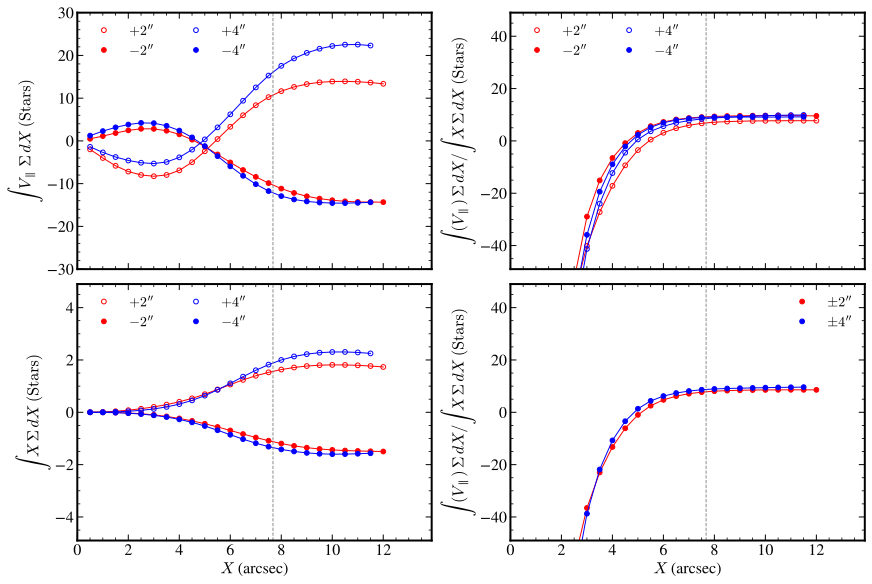

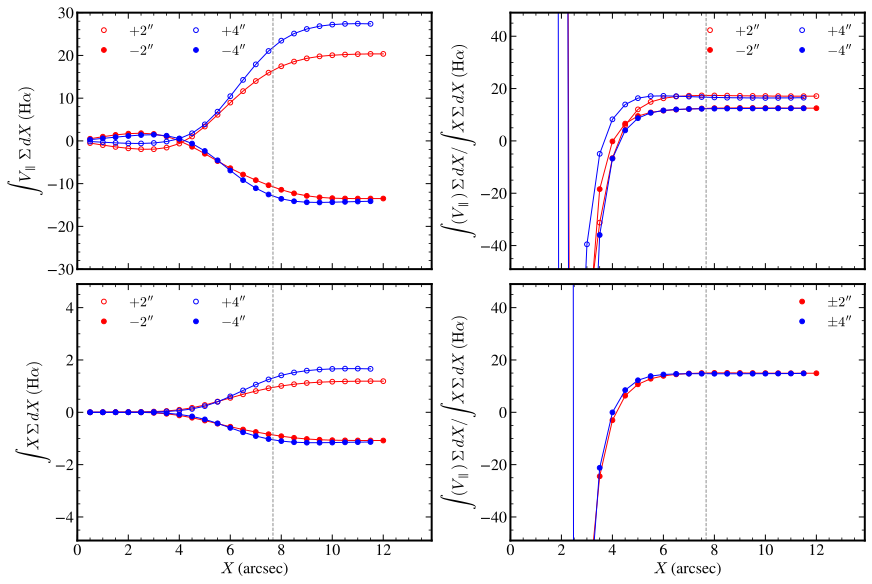

In [10]:
# Figure 5 combined panels: compute all slits, display only FIG_YABS_TO_PLOT = (2, 4)
fig_fig5_star, axes_fig5_star = plot_tw_figure5_combined(
    best_record=best_xv_record,
    pair_profiles_sym=pair_profiles_sym_stellar,
    yabs_to_plot=FIG_YABS_TO_PLOT,
    scale_plot=scale_plot,
    xlim=(0, 13.9),
    sigma_ylim=(-4.9, 4.9),
    tw_ylim=(-49, 49),
    Vsigma_ylim=(-30, 30),
    tracer="stellar",
    pair_list=pair_list_stellar,
    vsys=Vsys_use,
    show=True,
    savepath=TW_CENTER_DIR / f"figure5_combined_stellar_{galaxy_id}.png",
)

fig_fig5_ha, axes_fig5_ha = plot_tw_figure5_combined(
    best_record=None,
    pair_profiles_sym=pair_profiles_sym_ha,
    yabs_to_plot=FIG_YABS_TO_PLOT,
    scale_plot=5e2,
    xlim=(0, 13.9),
    sigma_ylim=(-4.9, 4.9),
    tw_ylim=(-49, 49),
    Vsigma_ylim=(-30, 30),
    tracer="ha",
    pair_list=pair_list_ha,
    vsys=Vsys_use,
    show=True,
    savepath=TW_CENTER_DIR / f"figure5_combined_ha_{galaxy_id}.png",
)


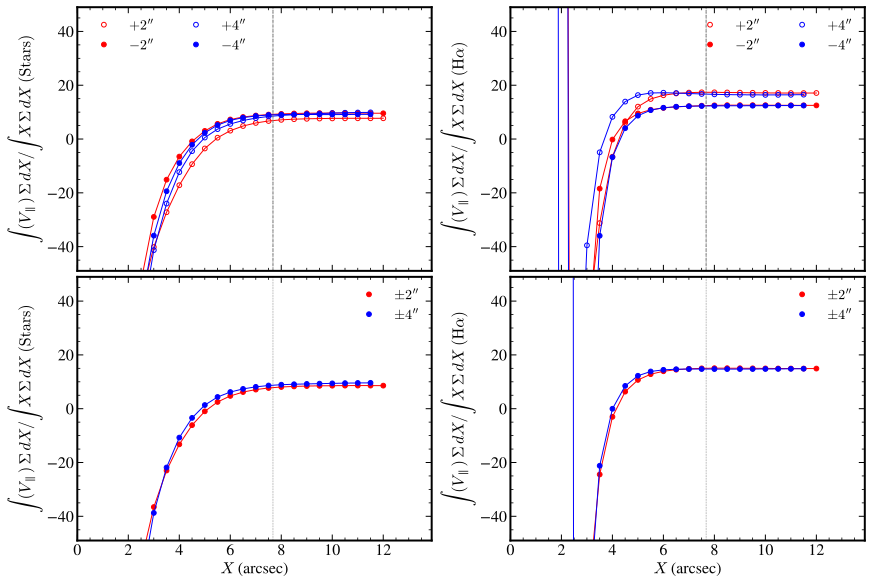

Saved Figure 8 top-panel combined plot to:
/home/jinelfy/TW_external/intermediate_cache/tw_center/figure8_top_combined_8312-12702.png


In [11]:
# top half of paper Figure 8: TW averaging + TW symmetric-slit, for Stars and Hα
# compute all slits, display only FIG_YABS_TO_PLOT = (2, 4)
fig_fig8_top, axes_fig8_top = plot_tw_figure8_top_combined(
    pair_list_stellar=pair_list_stellar,
    pair_profiles_sym_stellar=pair_profiles_sym_stellar,
    pair_list_ha=pair_list_ha,
    pair_profiles_sym_ha=pair_profiles_sym_ha,
    vsys=Vsys_use,
    yabs_to_plot=FIG_YABS_TO_PLOT,
    xlim=(0, 13.9),
    tw_ylim=(-49, 49),
    show=True,
    savepath=TW_CENTER_DIR / f"figure8_top_combined_{galaxy_id}.png",
)

print("Saved Figure 8 top-panel combined plot to:")
print(TW_CENTER_DIR / f"figure8_top_combined_{galaxy_id}.png")




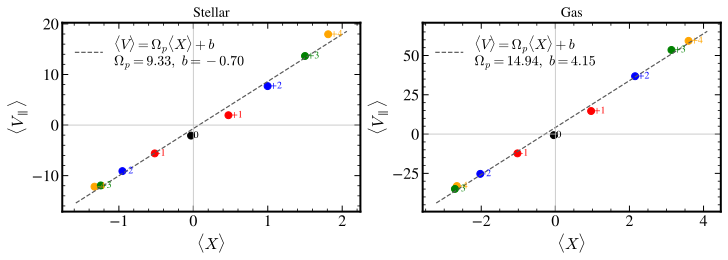

Saved TW fitting-method style plot to:
/home/jinelfy/TW_external/intermediate_cache/tw_center/figure8_tw_fitting_lastpoint_8312-12702.png
Fitted line parameters:
  Stellar slope     = 9.327044716533695
  Stellar intercept = -0.7001100698325384
  Gas slope         = 14.937849387181572
  Gas intercept     = 4.148388130459048
Final adopted TW fitting values:
  Op_TWfit_stellar = 9.327045
  Op_TWfit_gas     = 14.937849

TW fitting slit-point table (stellar):


,tracer,slit_label,slit_offset,X_mean_arcsec,V_mean_kms,Omega_from_single_slit,Sigma_sum_last
0,stellar,-4,-4,-1.327427,-12.187420,9.181236,11786.737957
1,stellar,-3,-3,-1.242951,-11.945776,9.610822,13527.228039
2,stellar,-2,-2,-0.952805,-9.109491,9.560713,15729.854979
3,stellar,-1,-1,-0.518128,-5.607828,10.823247,18184.142189
4,stellar,0,0,-0.030585,-2.089029,68.303136,20066.133354
5,stellar,+1,1,0.471628,1.942399,4.118498,19627.568053
6,stellar,+2,2,0.997820,7.700154,7.716981,17357.258440
7,stellar,+3,3,1.500169,13.653414,9.101253,14730.646101
8,stellar,+4,4,1.811327,17.955913,9.913126,12423.973467



TW fitting slit-point table (gas):


,tracer,slit_label,slit_offset,X_mean_arcsec,V_mean_kms,Omega_from_single_slit,Sigma_sum_last
0,gas,-4,-4,-2.657826,-33.086370,12.448658,213.397931
1,gas,-3,-3,-2.710846,-34.904757,12.875966,243.022082
2,gas,-2,-2,-2.025873,-25.316815,12.496742,266.326247
3,gas,-1,-1,-1.022751,-12.274338,12.001291,287.540832
4,gas,0,0,-0.040946,-0.697930,17.045091,307.293912
5,gas,+1,1,0.965465,14.669951,15.194693,298.719700
6,gas,+2,2,2.152395,36.823735,17.108264,276.348070
7,gas,+3,3,3.133599,53.540386,17.085909,259.725478
8,gas,+4,4,3.595774,59.330161,16.499968,230.761075



Saved slit-by-slit TW fitting point tables to:
/home/jinelfy/TW_external/intermediate_cache/tw_center/twfit_points_stellar_8312-12702.csv
/home/jinelfy/TW_external/intermediate_cache/tw_center/twfit_points_gas_8312-12702.csv


In [12]:
fig_tw_fit, axes_tw_fit, summary_tw_fit = plot_tw_fitting_method_lastpoint(
    pair_list_stellar=pair_list_stellar,
    pair_list_ha=pair_list_ha,
    vsys=Vsys_use,
    slit0_stellar=slit0_stellar,
    slit0_ha=slit0_ha,
    show=True,
    savepath=TW_CENTER_DIR / f"figure8_tw_fitting_lastpoint_{galaxy_id}.png",
)

print("Saved TW fitting-method style plot to:")
print(TW_CENTER_DIR / f"figure8_tw_fitting_lastpoint_{galaxy_id}.png")
print("Fitted line parameters:")
print("  Stellar slope     =", summary_tw_fit["stellar_slope"])
print("  Stellar intercept =", summary_tw_fit["stellar_intercept"])
print("  Gas slope         =", summary_tw_fit["gas_slope"])
print("  Gas intercept     =", summary_tw_fit["gas_intercept"])
# =========================================================
# Extract final adopted TW fitting values and slit-by-slit <X>, <V>
# =========================================================

# Final adopted TW fitting values (slope of <V> vs <X>)
Op_TWfit_stellar = float(summary_tw_fit["stellar_slope"]) if np.isfinite(summary_tw_fit["stellar_slope"]) else np.nan
Op_TWfit_gas     = float(summary_tw_fit["gas_slope"])     if np.isfinite(summary_tw_fit["gas_slope"]) else np.nan

print("Final adopted TW fitting values:")
print(f"  Op_TWfit_stellar = {Op_TWfit_stellar:.6f}")
print(f"  Op_TWfit_gas     = {Op_TWfit_gas:.6f}")

# Raw slit-by-slit fitting points
twfit_records_stellar = summary_tw_fit["stellar_records"]
twfit_records_gas     = summary_tw_fit["gas_records"]

# Convert to tables
df_twfit_stellar = pd.DataFrame(twfit_records_stellar).copy()
df_twfit_gas     = pd.DataFrame(twfit_records_gas).copy()

# Rename to more explicit scientific column names
rename_map = {
    "x_last": "X_mean_arcsec",       # <X>
    "y_last": "V_mean_kms",          # <V>
    "tw_last": "Omega_from_single_slit",
    "sum_sigma_last": "Sigma_sum_last",
}

df_twfit_stellar.rename(columns=rename_map, inplace=True)
df_twfit_gas.rename(columns=rename_map, inplace=True)

# Add tracer label
df_twfit_stellar["tracer"] = "stellar"
df_twfit_gas["tracer"] = "gas"

# Reorder columns if present
preferred_cols = [
    "tracer",
    "slit_label",
    "slit_offset",
    "X_mean_arcsec",
    "V_mean_kms",
    "Omega_from_single_slit",
    "Sigma_sum_last",
]
df_twfit_stellar = df_twfit_stellar[[c for c in preferred_cols if c in df_twfit_stellar.columns]]
df_twfit_gas     = df_twfit_gas[[c for c in preferred_cols if c in df_twfit_gas.columns]]

print("\nTW fitting slit-point table (stellar):")
display(df_twfit_stellar)

print("\nTW fitting slit-point table (gas):")
display(df_twfit_gas)

# Save
twfit_star_csv = TW_CENTER_DIR / f"twfit_points_stellar_{galaxy_id}.csv"
twfit_gas_csv  = TW_CENTER_DIR / f"twfit_points_gas_{galaxy_id}.csv"

df_twfit_stellar.to_csv(twfit_star_csv, index=False)
df_twfit_gas.to_csv(twfit_gas_csv, index=False)

print("\nSaved slit-by-slit TW fitting point tables to:")
print(twfit_star_csv)
print(twfit_gas_csv)

In [13]:
# =========================================================
# Final adopted TW values using all downstream CALC_YABS_LIST slits at the fixed Xc/Yc/Vsys
# =========================================================

Op_TWmean_stellar, twavg_vals_stellar = adopted_twavg_from_pair_list_literature(
    pair_list_stellar, vsys=Vsys_use
)

Op_TWmean_gas, twavg_vals_gas = adopted_twavg_from_pair_list_literature(
    pair_list_ha, vsys=Vsys_use
)

Op_TWsymm_stellar, twsymm_vals_stellar = adopted_twsymm_from_pair_profiles(
    pair_profiles_sym_stellar
)

Op_TWsymm_gas, twsymm_vals_gas = adopted_twsymm_from_pair_profiles(
    pair_profiles_sym_ha
)

# TW fitting method (already obtained from summary_tw_fit)
Op_TWfit_stellar = float(summary_tw_fit["stellar_slope"]) if np.isfinite(summary_tw_fit["stellar_slope"]) else np.nan
Op_TWfit_gas     = float(summary_tw_fit["gas_slope"])     if np.isfinite(summary_tw_fit["gas_slope"]) else np.nan

print("Final adopted TW values:")
print(f"  Op_TWmean_stellar = {Op_TWmean_stellar:.6f}")
print(f"  Op_TWmean_gas     = {Op_TWmean_gas:.6f}")
print(f"  Op_TWsymm_stellar = {Op_TWsymm_stellar:.6f}")
print(f"  Op_TWsymm_gas     = {Op_TWsymm_gas:.6f}")
print(f"  Op_TWfit_stellar  = {Op_TWfit_stellar:.6f}")
print(f"  Op_TWfit_gas      = {Op_TWfit_gas:.6f}")

print("Numbers of valid downstream measurements used after fixing Xc/Yc/Vsys:")
print(f"  TW averaging stellar slits   = {len(twavg_vals_stellar)}")
print(f"  TW averaging gas slits       = {len(twavg_vals_gas)}")
print(f"  TW symmetric stellar pairs   = {len(twsymm_vals_stellar)}")
print(f"  TW symmetric gas pairs       = {len(twsymm_vals_gas)}")
print(f"  TW fitting stellar points    = {len(summary_tw_fit['stellar_records'])}")
print(f"  TW fitting gas points        = {len(summary_tw_fit['gas_records'])}")

Final adopted TW values:
  Op_TWmean_stellar = 8.763479
  Op_TWmean_gas     = 14.455740
  Op_TWsymm_stellar = 8.751789
  Op_TWsymm_gas     = 14.638739
  Op_TWfit_stellar  = 9.327045
  Op_TWfit_gas      = 14.937849
Numbers of valid downstream measurements used after fixing Xc/Yc/Vsys:
  TW averaging stellar slits   = 8
  TW averaging gas slits       = 8
  TW symmetric stellar pairs   = 4
  TW symmetric gas pairs       = 4
  TW fitting stellar points    = 9
  TW fitting gas points        = 9


In [ ]:
# 用来处理总表csv文件--删除某些行
import pandas as pd
from pathlib import Path

MASTER_CSV = Path("/home/jinelfy/TW_external/intermediate_cache/master_table.csv")

cols_to_drop = [
    "N_twavg_stellar","N_twavg_gas","N_twsymm_stellar",
    "N_twsymm_gas","N_twfit_stellar","N_twfit_gas","Op_TWmean_stellar",
    "Op_TWmean_gas","Op_TWsymm_stellar","Op_TWsymm_gas","Op_TWfit_stellar","Op_TWfit_gas"]

df = pd.read_csv(MASTER_CSV)

existing = [c for c in cols_to_drop if c in df.columns]
if existing:
    df = df.drop(columns=existing)
    df.to_csv(MASTER_CSV, index=False)
    print("Dropped columns:", existing)
else:
    print("No matching columns found. Nothing to drop.")

In [ ]:
# =========================================================
# Save best TW center / systemic velocity into master_table.csv
# =========================================================
def upsert_master_row(master_csv, row_dict, key="plateifu"):
    master_csv = Path(master_csv)

    if master_csv.exists():
        df = pd.read_csv(master_csv)
    else:
        df = pd.DataFrame()

    row_df = pd.DataFrame([row_dict])

    if df.empty:
        df = row_df.copy()
    else:
        if key not in df.columns:
            df[key] = None

        row_key = row_dict[key]
        mask = df[key].astype(str) == str(row_key)

        for col in row_df.columns:
            if col not in df.columns:
                df[col] = pd.NA
        for col in df.columns:
            if col not in row_df.columns:
                row_df[col] = pd.NA

        row_df = row_df[df.columns]

        if mask.any():
            idx = df.index[mask][0]
            for col, val in row_dict.items():
                df.loc[idx, col] = val
        else:
            df = pd.concat([df, row_df], ignore_index=True)

    df.to_csv(master_csv, index=False)
    print(f"Updated master table: {master_csv}")
    return df

master_row = {
    "plateifu": galaxy_id,

    # best center / systemic velocity
    "Xc_best_arcsec": float(best_xv_record["xc_arcsec"]),
    "Yc_best_arcsec": float(best_xv_record["yc_arcsec"]),
    "Vsys_best": float(best_xv_record["vsys"]),
}

df_master = upsert_master_row(MASTER_CSV, master_row, key="plateifu")
df_master.tail()

NameError: name 'best_xv_record' is not defined


## 17. PA-disk Monte Carlo TW calculation

This section reads the 100 PA-dependent Recast maps generated in `PA_DISK.ipynb`.  For each Monte Carlo realization it repeats the literature-strict centering step, uses the corresponding `Xc_use`, `Yc_use`, and `Vsys_use`, recomputes the TW averaging, symmetric-slit, and fitting-method values, then writes the Monte Carlo mean and standard deviation back to `MASTER_CSV`.


In [7]:

# =========================================================
# 17. PA-disk Monte Carlo TW calculation from saved Recast maps
# =========================================================
from pathlib import Path
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory produced by the final PA_DISK.ipynb MC-Recast section.
MC_RECAST_DIR = CACHE_ROOT / "recast_mc" / galaxy_id / "PA_disk_kin_MC_star"
MC_MANIFEST_CSV = MC_RECAST_DIR / "recast_PA_MC_manifest.csv"

# Output directory for this TW Monte Carlo run.
TW_MC_DIR = TW_CENTER_DIR / f"pa_disk_recast_mc_tw_{galaxy_id}"
TW_MC_DIR.mkdir(parents=True, exist_ok=True)

if not MC_MANIFEST_CSV.exists():
    raise FileNotFoundError(
        "Cannot find the PA-MC Recast manifest:\n"
        f"  {MC_MANIFEST_CSV}\n\n"
        "Please run the PA_DISK.ipynb section that saves the 100 PA-dependent Recast maps first."
    )

mc_manifest = pd.read_csv(MC_MANIFEST_CSV)
if "recast_npz" not in mc_manifest.columns:
    raise KeyError(f"Manifest {MC_MANIFEST_CSV} does not contain column 'recast_npz'.")

# Keep only existing npz files. This prevents one missing/broken file from silently entering the run.
mc_manifest["recast_npz"] = mc_manifest["recast_npz"].astype(str)
exists_mask = mc_manifest["recast_npz"].map(lambda p: Path(p).exists())
if not exists_mask.all():
    missing = mc_manifest.loc[~exists_mask, "recast_npz"].tolist()
    raise FileNotFoundError("Some MC Recast files listed in the manifest do not exist:\n" + "\n".join(missing[:10]))

# Number of MC realizations to use.  Set to None to use all rows in the manifest.
N_MC_TO_RUN = 100
if N_MC_TO_RUN is not None:
    mc_manifest_run = mc_manifest.iloc[:int(N_MC_TO_RUN)].copy()
else:
    mc_manifest_run = mc_manifest.copy()

print(f"Loaded MC Recast manifest: {MC_MANIFEST_CSV}")
print(f"Number of MC Recast maps to process: {len(mc_manifest_run)}")
print(f"TW MC output directory: {TW_MC_DIR}")



Loaded MC Recast manifest: /home/jinelfy/TW_external/intermediate_cache/recast_mc/8312-12702/PA_disk_kin_MC_star/recast_PA_MC_manifest.csv
Number of MC Recast maps to process: 100
TW MC output directory: /home/jinelfy/TW_external/intermediate_cache/tw_center/pa_disk_recast_mc_tw_8312-12702


In [8]:

def _axis_from_grid_or_vector(arr, axis):
    """Return a 1D x/y axis from either a 2D coordinate grid or a 1D vector."""
    arr = np.asarray(arr, dtype=float)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2:
        return arr[0, :].astype(float) if axis == "x" else arr[:, 0].astype(float)
    raise ValueError(f"Cannot interpret coordinate array with ndim={arr.ndim} as {axis}-axis.")


def load_mc_recast_npz(npz_path):
    """Load one PA-MC Recast map and return arrays using the same names as the nominal run."""
    npz_path = Path(npz_path)
    data = np.load(npz_path, allow_pickle=True)

    required = [
        "stellar_sigma_recast", "stellar_vel_recast",
        "ha_sigma_recast", "ha_vel_recast",
        "display_mask_star", "display_mask_ha",
        "x_arcsec", "y_arcsec",
    ]
    missing = [k for k in required if k not in data.files]
    if missing:
        raise KeyError(f"{npz_path} is missing required arrays: {missing}")

    fig4_mc = {
        "stellar_sigma_recast": np.asarray(data["stellar_sigma_recast"], dtype=float),
        "stellar_vel_recast":   np.asarray(data["stellar_vel_recast"], dtype=float),
        "ha_sigma_recast":      np.asarray(data["ha_sigma_recast"], dtype=float),
        "ha_vel_recast":        np.asarray(data["ha_vel_recast"], dtype=float),
        "display_mask_star":    np.asarray(data["display_mask_star"], dtype=bool),
        "display_mask_ha":      np.asarray(data["display_mask_ha"], dtype=bool),
    }

    # Optional masks/metadata, kept if present for downstream diagnostics.
    for key in ["geometry_mask_recast", "slit_mask_common", "extent_arcsec"]:
        if key in data.files:
            fig4_mc[key] = data[key]

    x_axis_mc = _axis_from_grid_or_vector(data["x_arcsec"], axis="x")
    y_axis_mc = _axis_from_grid_or_vector(data["y_arcsec"], axis="y")

    meta = {}
    for key in ["PA_disk_kin_deg", "PA_bar_deg", "phi_bar_disk_deg", "bar_half_width_arcsec"]:
        meta[key] = float(np.asarray(data[key]).squeeze()) if key in data.files else np.nan

    return fig4_mc, x_axis_mc, y_axis_mc, meta


def compute_twfit_summary_no_plot(pair_list_stellar, pair_list_ha, vsys, slit0_stellar=None, slit0_ha=None):
    """Compute the TW fitting-method records and slopes without making a figure."""
    rec_star = _collect_twavg_fit_points_from_pair_list(pair_list_stellar, vsys=vsys)
    rec_ha = _collect_twavg_fit_points_from_pair_list(pair_list_ha, vsys=vsys)

    if slit0_stellar is not None:
        rec0s = _collect_twavg_fit_point_from_single_slit(
            slit0_stellar["x_seg"],
            slit0_stellar["sigma_prof"],
            slit0_stellar["vel_prof"],
            slit_offset=0,
            vsys=vsys,
        )
        if rec0s is not None:
            rec_star.append(rec0s)

    if slit0_ha is not None:
        rec0h = _collect_twavg_fit_point_from_single_slit(
            slit0_ha["x_seg"],
            slit0_ha["sigma_prof"],
            slit0_ha["vel_prof"],
            slit_offset=0,
            vsys=vsys,
        )
        if rec0h is not None:
            rec_ha.append(rec0h)

    rec_star = sorted(rec_star, key=lambda d: d["slit_offset"])
    rec_ha = sorted(rec_ha, key=lambda d: d["slit_offset"])

    x_star = np.array([r["x_last"] for r in rec_star], dtype=float)
    y_star = np.array([r["y_last"] for r in rec_star], dtype=float)
    x_ha = np.array([r["x_last"] for r in rec_ha], dtype=float)
    y_ha = np.array([r["y_last"] for r in rec_ha], dtype=float)

    slope_star, intercept_star = _fit_line_free_intercept(x_star, y_star)
    slope_ha, intercept_ha = _fit_line_free_intercept(x_ha, y_ha)

    return {
        "stellar_slope": slope_star,
        "stellar_intercept": intercept_star,
        "gas_slope": slope_ha,
        "gas_intercept": intercept_ha,
        "stellar_records": rec_star,
        "gas_records": rec_ha,
    }


def run_one_pa_recast_tw_mc(mc_row, verbose=False):
    """
    Run the full TW pipeline for one PA-dependent Recast map:
      1. load Recast map;
      2. redo literature-strict Xc/Yc/Vsys determination;
      3. rebuild downstream slit profiles at that Xc/Yc/Vsys;
      4. compute TWmean, TWsymm, and TWfit values.
    """
    mc_index = int(mc_row["mc_index"]) if "mc_index" in mc_row.index and np.isfinite(mc_row["mc_index"]) else int(mc_row.name)
    fig4_mc, x_axis_mc, y_axis_mc, meta_mc = load_mc_recast_npz(mc_row["recast_npz"])

    stellar_sigma_mc = fig4_mc["stellar_sigma_recast"]
    ha_sigma_mc = fig4_mc["ha_sigma_recast"]
    valid_mask_star_mc = fig4_mc["display_mask_star"]
    valid_mask_ha_mc = fig4_mc["display_mask_ha"]

    # Use the MC-specific bar half-width when available, but the explicit Y-list still controls
    # the adopted slit set in this notebook.
    bar_half_width_mc = meta_mc.get("bar_half_width_arcsec", np.nan)
    if not np.isfinite(bar_half_width_mc):
        bar_half_width_mc = float(master_csv_table["bar_half_width_arcsec"])

    strict_out_mc = run_literature_strict_centering_iteration(
        sigma_map=stellar_sigma_mc,
        vel_map=fig4_mc["stellar_vel_recast"],
        valid_mask=valid_mask_star_mc,
        x_axis=x_axis_mc,
        y_axis=y_axis_mc,
        xref_arcsec=float(Xref_arcsec),
        yref_arcsec=float(Yref_arcsec),
        vsys_ref=STRICT_TW_CONFIG["vsys_ref"],
        pixscale_arcsec=float(pixscale),
        bar_half_width_arcsec=float(bar_half_width_mc),
        slit_spacing_arcsec=1.0,
        slit_width_arcsec=2.0,
        max_offset_spaxel_yc=STRICT_TW_CONFIG["max_offset_spaxel_yc"],
        spaxel_step_yc=STRICT_TW_CONFIG["spaxel_step_yc"],
        max_offset_spaxel_xc=STRICT_TW_CONFIG["max_offset_spaxel_xc"],
        spaxel_step_xc=STRICT_TW_CONFIG["spaxel_step_xc"],
        vsys_range=STRICT_TW_CONFIG["vsys_range"],
        vsys_step=STRICT_TW_CONFIG["vsys_step"],
        xmin_for_convergence=STRICT_TW_CONFIG["xmin_for_convergence"],
        plateau_n=STRICT_TW_CONFIG["plateau_n"],
        plateau_rtol=STRICT_TW_CONFIG["plateau_rtol"],
        plateau_atol=STRICT_TW_CONFIG["plateau_atol"],
        require_convergence=STRICT_TW_CONFIG["require_convergence"],
        rejection_fraction=STRICT_TW_CONFIG["rejection_fraction"],
        max_iter=STRICT_TW_CONFIG["max_iter"],
        tol_center_arcsec=STRICT_TW_CONFIG["tol_center_arcsec"],
        tol_vsys=STRICT_TW_CONFIG["tol_vsys"],
        explicit_yabs_list=EXPLICIT_YABS_LIST,
        verbose=verbose,
    )

    best_xv_mc = strict_out_mc["best_xv_record"]
    Xc_use_mc = float(best_xv_mc["xc_arcsec"])
    Yc_use_mc = float(best_xv_mc["yc_arcsec"])
    Vsys_use_mc = float(best_xv_mc["vsys"])

    # Always use all requested downstream slits after Xc/Yc/Vsys are fixed.
    calc_yabs_list_mc = list(CALC_YABS_LIST)

    pair_list_stellar_mc, pair_summaries_stellar_mc, tw_mean_stellar_all_mc, tw_all_stellar_all_mc, obj_stellar_all_mc = final_pair_list_at_solution_literature(
        sigma_map=stellar_sigma_mc,
        vel_map=fig4_mc["stellar_vel_recast"],
        valid_mask=valid_mask_star_mc,
        x_axis=x_axis_mc,
        y_axis=y_axis_mc,
        xc_arcsec=Xc_use_mc,
        yc_arcsec=Yc_use_mc,
        vsys=Vsys_use_mc,
        yabs_list=calc_yabs_list_mc,
        slit_width_arcsec=2.0,
        xmin_for_convergence=STRICT_TW_CONFIG["xmin_for_convergence"],
        plateau_n=STRICT_TW_CONFIG["plateau_n"],
        plateau_rtol=STRICT_TW_CONFIG["plateau_rtol"],
        plateau_atol=STRICT_TW_CONFIG["plateau_atol"],
        require_convergence=False,
    )

    pair_list_ha_mc, pair_summaries_ha_mc, tw_mean_ha_all_mc, tw_all_ha_all_mc, obj_ha_all_mc = final_pair_list_at_solution_literature(
        sigma_map=ha_sigma_mc,
        vel_map=fig4_mc["ha_vel_recast"],
        valid_mask=valid_mask_ha_mc,
        x_axis=x_axis_mc,
        y_axis=y_axis_mc,
        xc_arcsec=Xc_use_mc,
        yc_arcsec=Yc_use_mc,
        vsys=Vsys_use_mc,
        yabs_list=calc_yabs_list_mc,
        slit_width_arcsec=2.0,
        xmin_for_convergence=STRICT_TW_CONFIG["xmin_for_convergence"],
        plateau_n=STRICT_TW_CONFIG["plateau_n"],
        plateau_rtol=STRICT_TW_CONFIG["plateau_rtol"],
        plateau_atol=STRICT_TW_CONFIG["plateau_atol"],
        require_convergence=False,
    )

    pair_profiles_sym_stellar_mc = build_tw_symmetric_slit_pairs(
        sigma_map=stellar_sigma_mc,
        vel_map=fig4_mc["stellar_vel_recast"],
        valid_mask=valid_mask_star_mc,
        x_axis=x_axis_mc,
        y_axis=y_axis_mc,
        xc_arcsec=Xc_use_mc,
        yc_arcsec=Yc_use_mc,
        vsys=Vsys_use_mc,
        bar_half_width_arcsec=max(calc_yabs_list_mc) if len(calc_yabs_list_mc) else bar_half_width_mc,
        slit_spacing_arcsec=1.0,
        slit_width_arcsec=2.0,
        explicit_yabs_list=calc_yabs_list_mc,
    )

    pair_profiles_sym_ha_mc = build_tw_symmetric_slit_pairs(
        sigma_map=ha_sigma_mc,
        vel_map=fig4_mc["ha_vel_recast"],
        valid_mask=valid_mask_ha_mc,
        x_axis=x_axis_mc,
        y_axis=y_axis_mc,
        xc_arcsec=Xc_use_mc,
        yc_arcsec=Yc_use_mc,
        vsys=Vsys_use_mc,
        bar_half_width_arcsec=max(calc_yabs_list_mc) if len(calc_yabs_list_mc) else bar_half_width_mc,
        slit_spacing_arcsec=1.0,
        slit_width_arcsec=2.0,
        explicit_yabs_list=calc_yabs_list_mc,
    )

    slit0_stellar_mc = obtain_single_slit_profile_with_velocity(
        sigma_map=stellar_sigma_mc,
        vel_map=fig4_mc["stellar_vel_recast"],
        valid_mask=valid_mask_star_mc,
        x_axis=x_axis_mc,
        y_axis=y_axis_mc,
        xc_arcsec=Xc_use_mc,
        y_center_arcsec=Yc_use_mc,
        slit_width_arcsec=2.0,
    )

    slit0_ha_mc = obtain_single_slit_profile_with_velocity(
        sigma_map=ha_sigma_mc,
        vel_map=fig4_mc["ha_vel_recast"],
        valid_mask=valid_mask_ha_mc,
        x_axis=x_axis_mc,
        y_axis=y_axis_mc,
        xc_arcsec=Xc_use_mc,
        y_center_arcsec=Yc_use_mc,
        slit_width_arcsec=2.0,
    )

    summary_tw_fit_mc = compute_twfit_summary_no_plot(
        pair_list_stellar=pair_list_stellar_mc,
        pair_list_ha=pair_list_ha_mc,
        vsys=Vsys_use_mc,
        slit0_stellar=slit0_stellar_mc,
        slit0_ha=slit0_ha_mc,
    )

    Op_TWmean_stellar_mc, twavg_vals_stellar_mc = adopted_twavg_from_pair_list_literature(pair_list_stellar_mc, vsys=Vsys_use_mc)
    Op_TWmean_gas_mc, twavg_vals_gas_mc = adopted_twavg_from_pair_list_literature(pair_list_ha_mc, vsys=Vsys_use_mc)
    Op_TWsymm_stellar_mc, twsymm_vals_stellar_mc = adopted_twsymm_from_pair_profiles(pair_profiles_sym_stellar_mc)
    Op_TWsymm_gas_mc, twsymm_vals_gas_mc = adopted_twsymm_from_pair_profiles(pair_profiles_sym_ha_mc)
    Op_TWfit_stellar_mc = float(summary_tw_fit_mc["stellar_slope"]) if np.isfinite(summary_tw_fit_mc["stellar_slope"]) else np.nan
    Op_TWfit_gas_mc = float(summary_tw_fit_mc["gas_slope"]) if np.isfinite(summary_tw_fit_mc["gas_slope"]) else np.nan

    result_row = {
        "plateifu": galaxy_id,
        "mc_index": mc_index,
        "recast_npz": str(mc_row["recast_npz"]),
        "PA_disk_kin_deg": meta_mc.get("PA_disk_kin_deg", np.nan),
        "PA_bar_deg": meta_mc.get("PA_bar_deg", np.nan),
        "phi_bar_disk_deg": meta_mc.get("phi_bar_disk_deg", np.nan),
        "bar_half_width_arcsec": bar_half_width_mc,
        "converged": bool(strict_out_mc.get("converged", False)),
        "Xc_use": Xc_use_mc,
        "Yc_use": Yc_use_mc,
        "Vsys_use": Vsys_use_mc,
        "XcVsys_objective": float(best_xv_mc.get("objective", np.nan)),
        "n_pairs_converged_centering": int(best_xv_mc.get("n_pairs_converged", 0)),
        "accepted_yabs_for_center_vsys": json.dumps(list(strict_out_mc.get("bar_yabs_list_final", []))),
        "Op_TWmean_stellar": Op_TWmean_stellar_mc,
        "Op_TWmean_gas": Op_TWmean_gas_mc,
        "Op_TWsymm_stellar": Op_TWsymm_stellar_mc,
        "Op_TWsymm_gas": Op_TWsymm_gas_mc,
        "Op_TWfit_stellar": Op_TWfit_stellar_mc,
        "Op_TWfit_gas": Op_TWfit_gas_mc,
        "N_twavg_stellar": len(twavg_vals_stellar_mc),
        "N_twavg_gas": len(twavg_vals_gas_mc),
        "N_twsymm_stellar": len(twsymm_vals_stellar_mc),
        "N_twsymm_gas": len(twsymm_vals_gas_mc),
        "N_twfit_stellar": len(summary_tw_fit_mc["stellar_records"]),
        "N_twfit_gas": len(summary_tw_fit_mc["gas_records"]),
    }

    fit_records = []
    for tracer, records in [("stellar", summary_tw_fit_mc["stellar_records"]), ("gas", summary_tw_fit_mc["gas_records"])]:
        for rec in records:
            fit_records.append({
                "plateifu": galaxy_id,
                "mc_index": mc_index,
                "tracer": tracer,
                "slit_label": rec.get("slit_label"),
                "slit_offset": rec.get("slit_offset"),
                "x_last": rec.get("x_last", np.nan),
                "y_last": rec.get("y_last", np.nan),
                "tw_last": rec.get("tw_last", np.nan),
                "sum_sigma_last": rec.get("sum_sigma_last", np.nan),
            })

    return result_row, fit_records


# =========================================================
# 18. TW fitting-method plot with PA-MC uncertainty on <X> and <V>
# =========================================================
def _fit_mean_line_from_df(df_points):
    x = df_points["x_mean"].to_numpy(dtype=float)
    y = df_points["y_mean"].to_numpy(dtype=float)
    return _fit_line_free_intercept(x, y)


def _make_mean_fit_points(mc_fit_df, tracer):
    sub = mc_fit_df.loc[mc_fit_df["tracer"] == tracer].copy()
    if sub.empty:
        return pd.DataFrame()

    grouped = []
    for slit_offset, g in sub.groupby("slit_offset"):
        xvals = pd.to_numeric(g["x_last"], errors="coerce").to_numpy(dtype=float)
        yvals = pd.to_numeric(g["y_last"], errors="coerce").to_numpy(dtype=float)
        good = np.isfinite(xvals) & np.isfinite(yvals)
        xvals = xvals[good]
        yvals = yvals[good]
        if xvals.size == 0:
            continue
        label = str(g["slit_label"].iloc[0])
        grouped.append({
            "tracer": tracer,
            "slit_offset": float(slit_offset),
            "slit_label": label,
            "x_mean": float(np.mean(xvals)),
            "x_std": float(np.std(xvals, ddof=1)) if xvals.size > 1 else 0.0,
            "y_mean": float(np.mean(yvals)),
            "y_std": float(np.std(yvals, ddof=1)) if yvals.size > 1 else 0.0,
            "n": int(xvals.size),
        })

    out = pd.DataFrame(grouped)
    if not out.empty:
        out = out.sort_values("slit_offset").reset_index(drop=True)
    return out


def _plot_nominal_records(ax, records):
    """Plot the original single-PA points in the background, if available."""
    if records is None:
        return
    for rec in records:
        x = rec.get("x_last", np.nan)
        y = rec.get("y_last", np.nan)
        off = rec.get("slit_offset", np.nan)
        if not (np.isfinite(x) and np.isfinite(y) and np.isfinite(off)):
            continue
        ax.plot(x, y, marker="o", linestyle="none", ms=5, color="0.75", alpha=0.75, zorder=1)


def _plot_mc_errorbar_fit_panel(ax, mean_df, nominal_records=None, tracer="stellar", slope_mean=np.nan, slope_std=np.nan):
    _plot_nominal_records(ax, nominal_records)

    if mean_df is None or mean_df.empty:
        ax.text(0.5, 0.5, "No valid MC fit points", ha="center", va="center", transform=ax.transAxes)
        return

    for _, r in mean_df.iterrows():
        off = float(r["slit_offset"])
        c = _slit_color(off)
        ax.errorbar(
            r["x_mean"], r["y_mean"],
            xerr=r["x_std"], yerr=r["y_std"],
            fmt="o", ms=7, capsize=3, color=c, ecolor=c,
            elinewidth=1.1, zorder=3,
        )
        ax.text(r["x_mean"], r["y_mean"], f" {r['slit_label']}", color=c, fontsize=10, va="center", ha="left")

    slope_line, intercept_line = _fit_mean_line_from_df(mean_df)
    x_all = mean_df["x_mean"].to_numpy(dtype=float)
    if np.isfinite(slope_line) and np.isfinite(intercept_line) and x_all.size >= 2:
        xmin, xmax = np.nanmin(x_all), np.nanmax(x_all)
        pad = 0.08 * (xmax - xmin) if np.isfinite(xmax - xmin) and xmax != xmin else 1.0
        xline = np.linspace(xmin - pad, xmax + pad, 300)
        yline = slope_line * xline + intercept_line
        label = (
            # rf"MC mean points fit: $\Omega_p={slope_line:.2f}$" + "\n" +
            rf"MC slope distribution: ${slope_mean:.2f}\pm{slope_std:.2f}$"
        )
        ax.plot(xline, yline, ls="--", lw=1.4, color="0.20", label=label, zorder=2)

    ax.axhline(0.0, color="0.75", lw=0.8)
    ax.axvline(0.0, color="0.75", lw=0.8)
    ax.set_xlabel(r"$\langle X \rangle$")
    ax.set_ylabel(r"$\langle V_{\parallel} \rangle$")
    ax.set_title("Stellar" if tracer == "stellar" else r"H$\alpha$")
    ax.legend(frameon=False, loc="best")


# =========================================================
# 19. Write PA-Recast MC TW values into MASTER_CSV
# =========================================================
def upsert_master_row(master_csv, row_dict, key="plateifu"):
    master_csv = Path(master_csv)
    if master_csv.exists():
        df = pd.read_csv(master_csv)
    else:
        df = pd.DataFrame()

    row_df = pd.DataFrame([row_dict])
    if df.empty:
        df = row_df.copy()
    else:
        if key not in df.columns:
            df[key] = None
        row_key = row_dict[key]
        mask = df[key].astype(str) == str(row_key)

        for col in row_df.columns:
            if col not in df.columns:
                df[col] = pd.NA
        for col in df.columns:
            if col not in row_df.columns:
                row_df[col] = pd.NA
        row_df = row_df[df.columns]

        if mask.any():
            idx = df.index[mask][0]
            for col, val in row_dict.items():
                df.loc[idx, col] = val
        else:
            df = pd.concat([df, row_df], ignore_index=True)

    df.to_csv(master_csv, index=False)
    print(f"Updated master table: {master_csv}")
    return df


def _summary_value(quantity, stat):
    sub = mc_summary_df.loc[mc_summary_df["quantity"] == quantity]
    if sub.empty:
        return np.nan
    return float(sub.iloc[0][stat])



In [12]:
# -------------------------------
# Run the 100 MC realizations
# -------------------------------
mc_rows = []
mc_fit_records = []

for run_i, (_, mc_row) in enumerate(mc_manifest_run.iterrows(), start=1):
    result_row, fit_records = run_one_pa_recast_tw_mc(mc_row, verbose=False)
    mc_rows.append(result_row)
    mc_fit_records.extend(fit_records)
    print(
        f"[{run_i:03d}/{len(mc_manifest_run):03d}] "
        f"MC={result_row['mc_index']:03d}, "
        f"PA={result_row['PA_disk_kin_deg']:.3f}, "
        f"Xc={result_row['Xc_use']:.3f}, Yc={result_row['Yc_use']:.3f}, Vsys={result_row['Vsys_use']:.3f}, "
        f"TWfit(star,gas)=({result_row['Op_TWfit_stellar']:.3f}, {result_row['Op_TWfit_gas']:.3f})"
    )

mc_tw_df = pd.DataFrame(mc_rows)
mc_fit_df = pd.DataFrame(mc_fit_records)

mc_tw_csv = TW_MC_DIR / f"tw_pa_recast_mc_values_{galaxy_id}.csv"
mc_fit_csv = TW_MC_DIR / f"tw_pa_recast_mc_fit_points_{galaxy_id}.csv"
mc_tw_df.to_csv(mc_tw_csv, index=False)
mc_fit_df.to_csv(mc_fit_csv, index=False)

print("\nSaved MC TW value table to:")
print(mc_tw_csv)
print("Saved MC TW fitting-point table to:")
print(mc_fit_csv)

# -------------------------------
# Summarize MC mean and uncertainty
# -------------------------------
TW_VALUE_COLUMNS = [
    "Op_TWmean_stellar", "Op_TWmean_gas",
    "Op_TWsymm_stellar", "Op_TWsymm_gas",
    "Op_TWfit_stellar", "Op_TWfit_gas",
]
CENTER_VALUE_COLUMNS = ["Xc_use", "Yc_use", "Vsys_use"]
COUNT_COLUMNS = [
    "N_twavg_stellar", "N_twavg_gas",
    "N_twsymm_stellar", "N_twsymm_gas",
    "N_twfit_stellar", "N_twfit_gas",
]

summary_rows = []
for col in TW_VALUE_COLUMNS + CENTER_VALUE_COLUMNS + COUNT_COLUMNS:
    vals = pd.to_numeric(mc_tw_df[col], errors="coerce").to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    summary_rows.append({
        "quantity": col,
        "mean": float(np.mean(vals)) if vals.size else np.nan,
        "std": float(np.std(vals, ddof=1)) if vals.size > 1 else np.nan,
        "median": float(np.median(vals)) if vals.size else np.nan,
        "p16": float(np.percentile(vals, 16)) if vals.size else np.nan,
        "p84": float(np.percentile(vals, 84)) if vals.size else np.nan,
        "n_finite": int(vals.size),
    })

mc_summary_df = pd.DataFrame(summary_rows)
mc_summary_csv = TW_MC_DIR / f"tw_pa_recast_mc_summary_{galaxy_id}.csv"
mc_summary_df.to_csv(mc_summary_csv, index=False)

print("\nPA-Recast Monte Carlo final adopted TW values:")
for col in TW_VALUE_COLUMNS:
    row = mc_summary_df.loc[mc_summary_df["quantity"] == col].iloc[0]
    print(f"  {col:20s} = {row['mean']:.6f} ± {row['std']:.6f}   (N={int(row['n_finite'])})")

print("\nNumbers of valid downstream measurements, averaged over MC realizations:")
for col in COUNT_COLUMNS:
    row = mc_summary_df.loc[mc_summary_df["quantity"] == col].iloc[0]
    print(f"  {col:20s} = {row['mean']:.2f} ± {row['std']:.2f}")

print("\nSaved MC summary table to:")
print(mc_summary_csv)

# -------------------------------
# Save mean <X>, <V> point table for plotting/debugging
# -------------------------------
mean_fit_star = _make_mean_fit_points(mc_fit_df, "stellar")
mean_fit_gas = _make_mean_fit_points(mc_fit_df, "gas")

mean_fit_points_csv = TW_MC_DIR / f"tw_pa_recast_mc_fit_points_mean_errorbars_{galaxy_id}.csv"
pd.concat([mean_fit_star, mean_fit_gas], ignore_index=True).to_csv(mean_fit_points_csv, index=False)

# -------------------------------
# Write PA-Recast MC TW values into MASTER_CSV
# -------------------------------
master_row_mc = {
    "plateifu": galaxy_id,
    "PA_recast_MC_n": int(len(mc_tw_df)),
    "PA_recast_MC_values_csv": str(mc_tw_csv),
    "PA_recast_MC_summary_csv": str(mc_summary_csv),
    "PA_recast_MC_fit_points_csv": str(mc_fit_csv),

    # MC mean center/systemic velocity from re-centering each PA-Recast map.
    "Xc_best_arcsec": _summary_value("Xc_use", "mean"),
    "Yc_best_arcsec": _summary_value("Yc_use", "mean"),
    "Vsys_best": _summary_value("Vsys_use", "mean"),
    "Xc_best_arcsec_err": _summary_value("Xc_use", "std"),
    "Yc_best_arcsec_err": _summary_value("Yc_use", "std"),
    "Vsys_best_err": _summary_value("Vsys_use", "std"),
}

for col in TW_VALUE_COLUMNS:
    master_row_mc[col] = _summary_value(col, "mean")
    master_row_mc[f"{col}_err"] = _summary_value(col, "std")
    master_row_mc[f"{col}_p16"] = _summary_value(col, "p16")
    master_row_mc[f"{col}_p84"] = _summary_value(col, "p84")
    n_val = _summary_value(col, "n_finite")
    master_row_mc[f"{col}_n"] = int(n_val) if np.isfinite(n_val) else 0

for col in COUNT_COLUMNS:
    master_row_mc[col] = _summary_value(col, "mean")
    master_row_mc[f"{col}_err"] = _summary_value(col, "std")

df_master_mc = upsert_master_row(MASTER_CSV, master_row_mc, key="plateifu")

print("\nMASTER_CSV columns updated for PA-Recast MC TW results:")
for col in TW_VALUE_COLUMNS:
    print(f"  {col} = {master_row_mc[col]:.6f} ± {master_row_mc[col + '_err']:.6f}")

print("Saved mean <X>, <V> errorbar table to:")
print(mean_fit_points_csv)

display(df_master_mc[df_master_mc["plateifu"].astype(str) == str(galaxy_id)])


[001/100] MC=000, PA=6.487, Xc=-1.250, Yc=-0.250, Vsys=3.095, TWfit(star,gas)=(8.847, 14.673)
[002/100] MC=001, PA=6.632, Xc=-1.250, Yc=-0.250, Vsys=3.095, TWfit(star,gas)=(8.745, 14.603)


[ERROR]: Traceback (most recent call last):
  File "/home/jinelfy/.conda/envs/python3.8/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_293629/2507347283.py", line 8, in <module>
    result_row, fit_records = run_one_pa_recast_tw_mc(mc_row, verbose=False)
  File "/tmp/ipykernel_293629/4208171091.py", line 120, in run_one_pa_recast_tw_mc
    strict_out_mc = run_literature_strict_centering_iteration(
  File "/tmp/ipykernel_293629/1160197223.py", line 582, in run_literature_strict_centering_iteration
    records_xv, best_xv_record, _ = find_Xc_vsys_best2_literature(
  File "/tmp/ipykernel_293629/1160197223.py", line 400, in find_Xc_vsys_best2_literature
    obj, pair_list, tw_mean, tw_all, pair_summaries = find_Xc_vsys_best1_literature(
  File "/tmp/ipykernel_293629/1160197223.py", line 325, in find_Xc_vsys_best1_literature
    conv = pair_tw_converged_value_literature(
  Fil

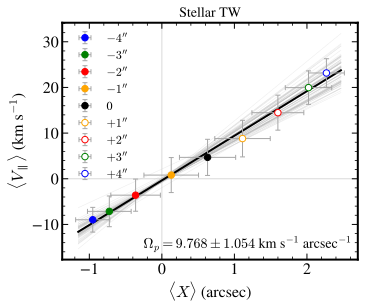

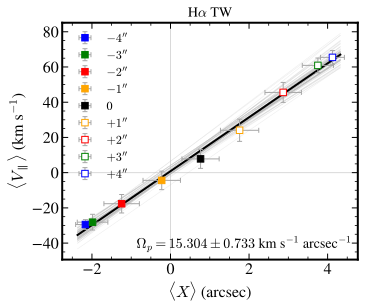

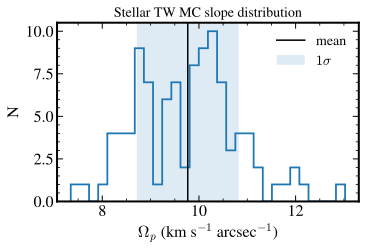

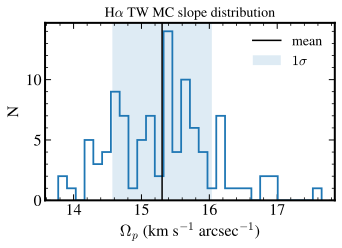

Saved TW MC figures and plotting tables to /home/jinelfy/TW_external/intermediate_cache/tw_center/pa_disk_recast_mc_tw_8312-12702
Slit errorbar summary: /home/jinelfy/TW_external/intermediate_cache/tw_center/pa_disk_recast_mc_tw_8312-12702/tw_pa_recast_mc_fit_points_errorbar_summary_8312-12702.csv
Per-MC fit line table: /home/jinelfy/TW_external/intermediate_cache/tw_center/pa_disk_recast_mc_tw_8312-12702/tw_pa_recast_mc_fit_lines_8312-12702.csv


In [ ]:
# =========================================================
# 20. TW fitting-method MC uncertainty plot
#     (same error convention and marker system as TW_OP_MK_MC.ipynb)
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%config InlineBackend.figure_formats = ['svg']

# -------------------------------
# 1. Paths and reload saved MC tables
# -------------------------------
galaxy_id = "8312-12702"
CACHE_ROOT = Path("/home/jinelfy/TW_external/intermediate_cache")
TW_CENTER_DIR = CACHE_ROOT / "tw_center"
TW_MC_DIR = TW_CENTER_DIR / f"pa_disk_recast_mc_tw_{galaxy_id}"

mc_tw_csv      = TW_MC_DIR / f"tw_pa_recast_mc_values_{galaxy_id}.csv"
mc_fit_csv     = TW_MC_DIR / f"tw_pa_recast_mc_fit_points_{galaxy_id}.csv"
mc_summary_csv = TW_MC_DIR / f"tw_pa_recast_mc_summary_{galaxy_id}.csv"

mc_tw_df = pd.read_csv(mc_tw_csv)
mc_fit_df = pd.read_csv(mc_fit_csv)
mc_summary_df = pd.read_csv(mc_summary_csv)

# -------------------------------
# 2. Per-slit MC error-bar table
# -------------------------------
def make_tw_mc_slit_summary(mc_fit_df, tracer):
    """
    One plotted point per slit.  Error bars are purely the MC scatter:
      xerr = std(<X>_last) over MC realisations;
      yerr = std(<V>_last) over MC realisations.
    """
    sub = mc_fit_df.loc[mc_fit_df["tracer"] == tracer].copy()
    if sub.empty:
        return pd.DataFrame()

    rows = []
    for slit_offset, g in sub.groupby("slit_offset"):
        x = pd.to_numeric(g["x_last"], errors="coerce").to_numpy(float)
        y = pd.to_numeric(g["y_last"], errors="coerce").to_numpy(float)
        good = np.isfinite(x) & np.isfinite(y)
        x = x[good]
        y = y[good]
        if x.size == 0:
            continue

        off = float(slit_offset)
        rows.append({
            "tracer": tracer,
            "slit_offset": off,
            "slit_label": "0" if np.isclose(off, 0.0) else f"{int(round(off)):+d}",
            "X_mean_arcsec_mean": float(np.nanmean(x)),
            "X_mean_arcsec_std":  float(np.nanstd(x, ddof=1)) if x.size > 1 else 0.0,
            "V_mean_kms_mean":    float(np.nanmean(y)),
            "V_mean_kms_std":     float(np.nanstd(y, ddof=1)) if y.size > 1 else 0.0,
            "n_mc": int(x.size),
        })

    return pd.DataFrame(rows).sort_values("slit_offset").reset_index(drop=True)


def build_tw_mc_fit_line_df(mc_fit_df, tracer):
    """
    Reconstruct one <V>-<X> free-intercept fit per MC realisation, so that
    the grey lines are the 100 individual MC fits, exactly analogous to MK.
    """
    sub = mc_fit_df.loc[mc_fit_df["tracer"] == tracer].copy()
    rows = []
    for mc_index, g in sub.groupby("mc_index"):
        x = pd.to_numeric(g["x_last"], errors="coerce").to_numpy(float)
        y = pd.to_numeric(g["y_last"], errors="coerce").to_numpy(float)
        good = np.isfinite(x) & np.isfinite(y)
        x = x[good]
        y = y[good]
        if x.size < 2:
            continue
        A = np.vstack([x, np.ones_like(x)]).T
        slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
        rows.append({
            "mc_index": mc_index,
            "tracer": tracer,
            "slope_kms_per_arcsec": float(slope),
            "intercept_kms": float(intercept),
            "n_slits": int(x.size),
        })
    return pd.DataFrame(rows).sort_values("mc_index").reset_index(drop=True)


tw_slit_summary_stellar = make_tw_mc_slit_summary(mc_fit_df, "stellar")
tw_slit_summary_gas     = make_tw_mc_slit_summary(mc_fit_df, "gas")
tw_fit_line_stellar     = build_tw_mc_fit_line_df(mc_fit_df, "stellar")
tw_fit_line_gas         = build_tw_mc_fit_line_df(mc_fit_df, "gas")

# Save the derived plotting tables, for reproducibility.
tw_slit_summary_csv = TW_MC_DIR / f"tw_pa_recast_mc_fit_points_errorbar_summary_{galaxy_id}.csv"
tw_fit_line_csv     = TW_MC_DIR / f"tw_pa_recast_mc_fit_lines_{galaxy_id}.csv"
pd.concat([tw_slit_summary_stellar, tw_slit_summary_gas], ignore_index=True).to_csv(tw_slit_summary_csv, index=False)
pd.concat([tw_fit_line_stellar, tw_fit_line_gas], ignore_index=True).to_csv(tw_fit_line_csv, index=False)

# -------------------------------
# 3. Plotting helpers: same marker/sign convention as MK
# -------------------------------
def _style_for_yabs_safe(yabs):
    """Use the notebook-level _style_for_yabs if available; otherwise fallback."""
    if "_style_for_yabs" in globals():
        return _style_for_yabs(yabs)
    y = int(round(abs(float(yabs))))
    cmap = {1: "orange", 2: "red", 3: "green", 4: "blue"}
    c = cmap.get(y, "0.4") if y != 0 else "black"
    return {
        "color": c,
        "label_pos": rf"$+{y}''$",
        "label_neg": rf"$-{y}''$",
        "label_sym": rf"$\pm {y}''$",
    }


def _mc_summary_value(quantity, stat):
    sub = mc_summary_df.loc[mc_summary_df["quantity"] == quantity]
    if sub.empty:
        return np.nan
    return float(sub.iloc[0][stat])


def plot_tw_mc_errorbars(
    slit_summary,
    fit_line_df,
    tracer="stellar",
    slope_quantity="Op_TWfit_stellar",
    annotate_points=True,
):
    """
    Plot <V>--<X> for the TW fitting method with PA-MC-derived x/y error bars.

    Final reported slope = mean(Op_TWfit_*) over the 100 MC realisations.
    Final reported error = std(Op_TWfit_*, ddof=1) over the same realisations.
    """
    fig, ax = plt.subplots(figsize=(5.4, 4.6))

    if slit_summary is None or slit_summary.empty:
        ax.text(0.5, 0.5, "No valid MC fit points", ha="center", va="center", transform=ax.transAxes)
        return fig, ax

    # One point per slit, with MC scatter as the errorbar.
    for _, row in slit_summary.iterrows():
        yoff = float(row["slit_offset"])
        if np.isclose(yoff, 0.0):
            st = {"color": "black", "label_pos": "0", "label_neg": "0"}
            face = "black"
            label = "0"
        else:
            st = _style_for_yabs_safe(abs(yoff))
            face = "white" if yoff > 0 else st["color"]
            label = st["label_pos"] if yoff > 0 else st["label_neg"]

        marker = "s" if str(tracer).lower() == "gas" else "o"

        ax.errorbar(
            row["X_mean_arcsec_mean"],
            row["V_mean_kms_mean"],
            xerr=row["X_mean_arcsec_std"],
            yerr=row["V_mean_kms_std"],
            fmt=marker,
            ms=6.5,
            color=st["color"],
            mfc=face,
            mec=st["color"],
            ecolor="0.65",
            elinewidth=1.0,
            capsize=2.5,
            label=label,
            zorder=3,
        )

        if annotate_points:
            slit_label = "0" if np.isclose(yoff, 0.0) else f"{int(round(yoff)):+d}"
            ax.text(
                row["X_mean_arcsec_mean"],
                row["V_mean_kms_mean"] - 1,
                f" {slit_label}",
                fontsize=8,
                va="center",
            )

    # Light grey individual MC realisation fits.
    x = slit_summary["X_mean_arcsec_mean"].to_numpy(float)
    xline = np.linspace(np.nanmin(x) - 0.2, np.nanmax(x) + 0.2, 300)
    for _, r in fit_line_df.iterrows():
        if np.isfinite(r.get("slope_kms_per_arcsec", np.nan)) and np.isfinite(r.get("intercept_kms", np.nan)):
            ax.plot(
                xline,
                r["slope_kms_per_arcsec"] * xline + r["intercept_kms"],
                color="0.75",
                lw=0.6,
                alpha=0.25,
                zorder=1,
            )

    # Mean MC relation: mean of the individual MC fitted slopes/intercepts.
    slope_line_mean = np.nanmean(fit_line_df["slope_kms_per_arcsec"].to_numpy(float))
    intercept_mean  = np.nanmean(fit_line_df["intercept_kms"].to_numpy(float))
    ax.plot(xline, slope_line_mean * xline + intercept_mean, "k-", lw=2.0, zorder=2)

    # Text uses the official saved Op_TWfit_* distribution, not a refit to the mean points.
    slope_mean = _mc_summary_value(slope_quantity, "mean")
    slope_std  = _mc_summary_value(slope_quantity, "std")
    n_finite   = int(_mc_summary_value(slope_quantity, "n_finite"))
    omega_label = (f"$\Omega_p = {slope_mean:.3f} \pm {slope_std:.3f}$ "
        + r"km s$^{-1}$ arcsec$^{-1}$"
    )

    ax.text(
        0.98, 0.10,
        omega_label,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14,
    )

    ax.axhline(0.0, color="0.85", lw=1.0, zorder=0)
    ax.axvline(0.0, color="0.85", lw=1.0, zorder=0)
    ax.set_xlabel(r"$\langle X \rangle$ (arcsec)")
    ax.set_ylabel(r"$\langle V_{\parallel} \rangle$ (km s$^{-1}$)")
    # ax.set_title("Stellar TW" if tracer == "stellar" else r"H$\alpha$ TW")
    ax.tick_params(direction="in", top=True, right=True)

    # Deduplicate legend labels.
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    handles_u, labels_u = [], []
    for h, lab in zip(handles, labels):
        if lab not in seen:
            handles_u.append(h)
            labels_u.append(lab)
            seen.add(lab)
    ax.legend(handles_u, labels_u, fontsize=12, frameon=False, loc="best")

    plt.tight_layout()
    return fig, ax

# -------------------------------
# 4. Draw and save figures
# -------------------------------
fig_tw_star_mc, ax_tw_star_mc = plot_tw_mc_errorbars(
    tw_slit_summary_stellar,
    tw_fit_line_stellar,
    tracer="stellar",
    slope_quantity="Op_TWfit_stellar",
    annotate_points=False,
)
fig_tw_star_mc.savefig(TW_MC_DIR / f"{galaxy_id}_OP_TWfit_stellar_MC_errorbars.png", dpi=300, bbox_inches="tight")
fig_tw_star_mc.savefig(TW_MC_DIR / f"{galaxy_id}_OP_TWfit_stellar_MC_errorbars.pdf", bbox_inches="tight")
plt.show()

fig_tw_gas_mc, ax_tw_gas_mc = plot_tw_mc_errorbars(
    tw_slit_summary_gas,
    tw_fit_line_gas,
    tracer="gas",
    slope_quantity="Op_TWfit_gas",
    annotate_points=False,
)
fig_tw_gas_mc.savefig(TW_MC_DIR / f"{galaxy_id}_OP_TWfit_gas_MC_errorbars.png", dpi=300, bbox_inches="tight")
fig_tw_gas_mc.savefig(TW_MC_DIR / f"{galaxy_id}_OP_TWfit_gas_MC_errorbars.pdf", bbox_inches="tight")
plt.show()


def plot_tw_mc_slope_hist(fit_df, slope_quantity, title):
    """Plot the distribution of MC TW fitting slopes in km/s/arcsec."""
    fig, ax = plt.subplots(figsize=(5.2, 3.8))

    vals = mc_tw_df[slope_quantity].to_numpy(float)
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins=30, histtype="step", lw=1.8)
    ax.axvline(np.nanmean(vals), color="k", lw=1.5, label="mean")
    ax.axvspan(
        np.nanmean(vals) - np.nanstd(vals, ddof=1),
        np.nanmean(vals) + np.nanstd(vals, ddof=1),
        alpha=0.15,
        label=r"$1\sigma$",
    )
    ax.set_xlabel(r"$\Omega_p$ (km s$^{-1}$ arcsec$^{-1}$)")
    ax.set_ylabel("N")
    ax.set_title(title)
    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(frameon=False)
    plt.tight_layout()
    return fig, ax

fig_tw_star_hist, ax_tw_star_hist = plot_tw_mc_slope_hist(
    tw_fit_line_stellar, "Op_TWfit_stellar", "Stellar TW MC slope distribution"
)
fig_tw_star_hist.savefig(TW_MC_DIR / f"{galaxy_id}_OP_TWfit_stellar_MC_slope_distribution.pdf", bbox_inches="tight")
plt.show()

fig_tw_gas_hist, ax_tw_gas_hist = plot_tw_mc_slope_hist(
    tw_fit_line_gas, "Op_TWfit_gas", r"H$\alpha$ TW MC slope distribution"
)
fig_tw_gas_hist.savefig(TW_MC_DIR / f"{galaxy_id}_OP_TWfit_gas_MC_slope_distribution.pdf", bbox_inches="tight")
plt.show()

print(f"Saved TW MC figures and plotting tables to {TW_MC_DIR.resolve()}")
print("Slit errorbar summary:", tw_slit_summary_csv)
print("Per-MC fit line table:", tw_fit_line_csv)
